# Imports

In [4]:
from HH_case_partition_MCMC import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde,skew,kurtosis,binom,entropy
from scipy.optimize import brentq
import os
from pickle import dump, load   

plt.style.use('ggplot')

# Partition making functions

In [ ]:
#Functions for generating flat or split partitions for starting partitions
def FlatPartition(n,y,N,m):
    if not (N>=0 and n>=0 and y>=0):
        raise ValueError("n, y and N must be non-negative integers.")
    if not (n>=y):
        raise ValueError("n must be greater or equal to y.")

    C = np.zeros(int(0.5*m*(m+3)))
    
    hh_size_s = int(n//N)
    hh_size_l = hh_size_s + 1
    
    N_l = n-hh_size_s*N
    N_s = N - N_l
    
    cases_less = int(y//N)
    cases_more = cases_less+1
    N_more = y - N*cases_less
    N_less = N - N_more

    
    k_less_s = IndexChange2dTo1d(hh_size_s, cases_less)
    if cases_more<=hh_size_s:
        k_more_s = IndexChange2dTo1d(hh_size_s, cases_more)
    k_less_l = IndexChange2dTo1d(hh_size_l, cases_less)
    k_more_l = IndexChange2dTo1d(hh_size_l, cases_more)
    k_more_s = None
    if N_more<=N_l:
        C[k_more_l] = N_more
        if N_less<= N_l-N_more:
            C[k_less_l] = N_less
        else:
            C[k_less_l] = N_l- N_more
            C[k_less_s] = N_less - C[k_less_l]
    else:
        C[k_more_l] = N_l
        C[k_more_s] = N_more - N_l
        C[k_less_s] = N_less
    return C

def SplitPartition(n,y,N,m):
    C = np.zeros(int(0.5*m*(m+3)))
    max_k =len(C)
    
    N_m = int(np.floor((n-N)/(m-1)))
    N_1 = int(N-np.ceil((n-N)/(m-1)))
    last_size = int(n-m*N_m-N_1)
    
    if y<N_1:
        C[0] = N_1-y
        C[1] = y
        C[IndexChange2dTo1d(last_size, 0)] = 1
        C[IndexChange2dTo1d(m, 0)] = N_m
    else:
        C[1] = N_1
        y -= N_1
        if y< m*N_m:
            C[IndexChange2dTo1d(last_size, 0)] = 1
            C[IndexChange2dTo1d(m, m)] = y//m

            if y%m ==0:
                C[IndexChange2dTo1d(m, 0)] = N_m - y//m
            else:
                C[IndexChange2dTo1d(m, int(y%m))] = 1
                C[IndexChange2dTo1d(m, 0)] =  N_m - y//m - 1
        else:
            C[IndexChange2dTo1d(m, m)] = N_m
            y-= N_m*m
            C[IndexChange2dTo1d(last_size, y)] = 1
            
            
    return C

# Generate synthetic data

In [ ]:
def GenerateSyntheticData(N,beta,hh_size_dist,eta):
    m = len(hh_size_dist) #max hh size (not including index case)
    max_k = int(0.5*m*(m+3)) 
    
    hh_size_dist_adjusted = np.array([i*p for i,p in enumerate(hh_size_dist,2)]) #Adjust distribution so that it is weighted by the size of the household
    hh_size_dist_adjusted = hh_size_dist_adjusted/sum(hh_size_dist_adjusted) # type: ignore
    
    household_sizes = np.random.choice(np.arange(1,m+1,1),p = hh_size_dist_adjusted,size=N) #Pick household sizes from distribution (not including index case)
    household_size_counts = [sum(np.where(household_sizes == n,1,0)) for n in range(1,m+1)]
    
    C = np.zeros(max_k)
    for n in range(1,m+1):
        fs_P = final_size_distribution_homogeneous_no_intro(n, 1, beta/n**eta, lambda t: np.exp(-t))
        final_sizes = np.random.choice(np.arange(0,n+1,1),p=fs_P,size= household_size_counts[n-1])
        final_size_counts = [sum(np.where(final_sizes == k,1,0)) for k in range(0,n+1)]
        for k in range(0,n+1):
            index = IndexChange2dTo1d(n, k)
            C[index] += final_size_counts[k]
    return C

Text(0.5, 1.0, 'Split Household Size Distribution')

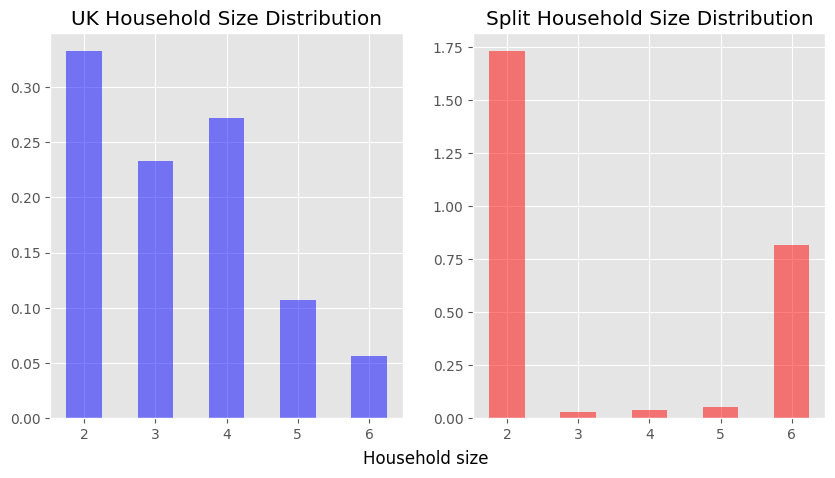

In [ ]:
#Set up household size distributions
hh_distribution_strings = ["UK","SPLIT"]

hh_dist_UK = [9698, 4526, 3961, 1249, 544]  # 2023 UK household size distribution from size 2 to 6+

hh_dist_UK_weighted = np.array([i*p for i,p in enumerate(hh_dist_UK,2)]) #Adjust distribution so that it is weighted by the size of the household
hh_dist_UK_weighted = hh_dist_UK_weighted/sum(hh_dist_UK_weighted)
UK_mu = np.dot(hh_dist_UK_weighted,np.arange(2,7,1))

hh_dist_split_weighted_func = lambda x: np.array([p*i for i,p in  enumerate([x,0.01,0.01,0.01,1-x],2)])
to_min = lambda x: np.dot(hh_dist_split_weighted_func(x)/sum(hh_dist_split_weighted_func(x)),np.arange(2,7,1)) - UK_mu

a = brentq(to_min,0,1,xtol = 1e-10) # Find the value of a that gives the same mean as the UK distribution when weighted by size
hh_dist_split = [a,0.01,0.01,0.01,1-a] # type: ignore # Split household size distribution with same mean as UK distribution when weighted by size
hh_dist_split_weighted = hh_dist_split_weighted_func(a) # Adjust distribution so that it is weighted by the size of the household

fig,axs = plt.subplots(1,2,figsize=(10,5),sharex=True)
fig.supxlabel("Household size")
axs[0].bar(np.arange(2,7,1),hh_dist_UK_weighted, width = 0.5, color = 'blue', alpha = 0.5, label = "UK")
axs[0].set_title("UK Household Size Distribution")
axs[1].bar(np.arange(2,7,1),hh_dist_split_weighted, width = 0.5, color = 'red', alpha = 0.5, label = "Split")
axs[1].set_title("Split Household Size Distribution")

In [31]:
# Check if dataset pickle files exist or need to be generated
N_synthetics = 100
N_households = 100
beta_values = [0.1, 0.25, 0.5, 1, 1.5]
eta_values = [0,0.5,1]

m = len(hh_dist_UK)

dot_for_cases = np.concatenate([np.arange(0, n + 1) for n in range(1, m + 1)])
dot_for_contacts = np.concatenate([np.zeros(n + 1) + n for n in range(1, m + 1)])

high_info_datasets = {pop: {
					  	eta: {
							beta: np.zeros((N_synthetics,int(0.5*m*(m+3)))) 
							for beta in beta_values}
						for eta in eta_values}
					  for pop in hh_distribution_strings}

low_info_datasets = {pop: {
					  	eta: {
							beta: np.zeros((N_synthetics,3))
							for beta in beta_values}
						for eta in eta_values}
					 for pop in hh_distribution_strings}
	

for hh_dist_i, hh_dist in enumerate([hh_dist_UK, hh_dist_split]):
	filename_hi = 'synthetic_datasets/high_info_datasets_' + hh_distribution_strings[hh_dist_i] + '.pkl'
	filename_li = 'synthetic_datasets/low_info_datasets_' + hh_distribution_strings[hh_dist_i] + '.pkl'

	if os.path.exists(filename_hi) and os.path.exists(filename_li):
		print('Loading synthetic datasets for ' + hh_distribution_strings[hh_dist_i] + ' household distribution from pickle files...')
		with open(filename_hi, 'rb') as f:
			high_info_datasets[hh_distribution_strings[hh_dist_i]] = load(f)
		with open(filename_li, 'rb') as f:
			low_info_datasets[hh_distribution_strings[hh_dist_i]] = load(f)
	else:
		print('Generating synthetic datasets for ' + hh_distribution_strings[hh_dist_i] + ' household size distribution...')
		# Generate synthetic data
		for eta in eta_values:
			for beta in beta_values:
				for ds in range(N_synthetics):
					high_info_datasets[hh_distribution_strings[hh_dist_i]][eta][beta][ds] = GenerateSyntheticData(N_households, beta, hh_dist, eta)
					
					n = high_info_datasets[hh_distribution_strings[hh_dist_i]][eta][beta][ds].dot(dot_for_contacts)
					y = high_info_datasets[hh_distribution_strings[hh_dist_i]][eta][beta][ds].dot(dot_for_cases)
					low_info_datasets[hh_distribution_strings[hh_dist_i]][eta][beta][ds] = [N_households, n, y]
		with open(filename_hi, 'wb') as f:
			dump(high_info_datasets[hh_distribution_strings[hh_dist_i]],f)
		with open(filename_li, 'wb') as f:
			dump(low_info_datasets[hh_distribution_strings[hh_dist_i]],f)

Loading synthetic datasets for UK household distribution from pickle files...
Loading synthetic datasets for SPLIT household distribution from pickle files...


In [30]:
low_info_datasets["UK"][0.5][1][:]


array([[100., 214., 141.],
       [100., 248., 149.],
       [100., 249., 165.],
       [100., 255., 173.],
       [100., 235., 166.],
       [100., 228., 155.],
       [100., 244., 152.],
       [100., 227., 149.],
       [100., 235., 161.],
       [100., 243., 158.],
       [100., 244., 161.],
       [100., 242., 150.],
       [100., 237., 167.],
       [100., 197., 130.],
       [100., 238., 179.],
       [100., 223., 139.],
       [100., 241., 159.],
       [100., 244., 173.],
       [100., 229., 143.],
       [100., 228., 157.],
       [100., 239., 165.],
       [100., 235., 143.],
       [100., 226., 162.],
       [100., 253., 175.],
       [100., 234., 163.],
       [100., 230., 163.],
       [100., 230., 145.],
       [100., 222., 142.],
       [100., 239., 158.],
       [100., 221., 135.],
       [100., 235., 169.],
       [100., 224., 156.],
       [100., 232., 147.],
       [100., 230., 155.],
       [100., 249., 160.],
       [100., 235., 154.],
       [100., 233., 162.],
 

# Test 1: Starting point is forgotten

MCMC fits to the UK synthetic data for a variety of values of $\beta$ and $\eta$ and two extreme starting partitions:

- Flat partition: all households of approximately the same size
- Split partition: Households either maximum size or minimum size

Checking to see if the initial partition is forgotten as would be expected for an MCMC run.

In [184]:
N_synthetics = 5

In [ ]:
def PlotResults1(results,n_chains,KDE=False,filename = None):
    fig,ax = plt.subplots(2,2,figsize=(15,10))
    x_max=0
    #Log_likelihood plots
    ax[1,1].set_ylabel("Density")
    ax[1,1].set_xlabel("Transmission rate " + r"$(\beta )$")
    ax[0,0].set_ylabel("Log-likelihood")
    ax[1,0].set_ylabel("Transmission rate " + r"$(\beta )$")
    ax[0,1].set_ylabel("Entropy")

    SAR_values =  [round(100*results["C"][i][0].dot(dot_for_cases)/results["C"][i][0].dot(dot_for_contacts)) for i in range(n_chains)]
    max_SAR = max(SAR_values)
    min_SAR = min(SAR_values)

    colours = [[(SAR-min_SAR)/(max_SAR-min_SAR),-(SAR-max_SAR)/(max_SAR-min_SAR),0] for SAR in SAR_values]
    for i in range(n_chains):
       
        ax[0,0].plot(results["llhs"][i],alpha=0.5)
        
        #Beta chains
        ax[1,0].plot(results["beta"][i],alpha=0.5)
        
        ax[0,1].plot(results["entropies"][i],alpha= 0.5)
        
        #Beta histogram

        betas = results["beta"][i][len(results["beta"][i])//10:]
        ax[1,1].hist(betas,bins=100,density=True,color = colours[i],alpha = 0.5,label = "SAR=" +str(SAR_values[i]) + "%")
        x_max = max(max(betas),x_max)
        
        #CI = np.percentile(betas,[2.5,97.5])
        #ax[1,1].vlines(CI,0,4,linestyle="--",color = "black")
        #ax[1,1].vlines(np.mean(betas),0,6,color = "black")

        if KDE:
            KDE = gaussian_kde(betas)
            X = np.linspace(0,x_max,1000)
            ax[1,1].plot(X,KDE(X),color="blue")
    ax[1,1].set_xlim(0,x_max)
    ax[1,1].legend()
    if filename != None:
        plt.savefig(filename)

## Flat initial partition

In [207]:
#Check if results pickle files exist or need to be generated
results_flat_start = {}
for eta in eta_values:
    print("eta = ", eta)
    results_flat_start[eta] = {}
    for beta in beta_values:
        print("beta = ", beta)
        filename = "testing_results/forget_start_tests/flat_partition_results_eta=" + str(eta) + "_beta=" + str(beta) + ".pkl"


        if os.path.exists(filename):
            print("File found, loading results")
            with open(filename,"rb") as f:
                results_flat_start[eta][beta] = load(f)
        else:
            print("File not found, generating results")
            n_iters = int(2e6)
            thin = 100
                
            results_flat_start_eta_beta = {"C": np.zeros((N_synthetics,1+n_iters//thin,int(0.5*m*(m+3)))),
                                        "llhs": np.zeros((N_synthetics,1+n_iters//thin)),
                                        "beta": np.zeros((N_synthetics,1+n_iters//thin)),
                                        "entropies": np.zeros((N_synthetics,1+n_iters//thin)),
                                        "chosen_indices": np.zeros((N_synthetics,(n_iters//thin),2),dtype=int)}
            for ds in range(N_synthetics):
                N, n, y = low_info_datasets["UK"][eta][beta][ds]
                C0_flat = FlatPartition(n,y,N,m)

                (results_flat_start_eta_beta["C"][ds], 
                results_flat_start_eta_beta["llhs"][ds], 
                results_flat_start_eta_beta["beta"][ds], _, _, 
                results_flat_start_eta_beta["entropies"][ds],
                results_flat_start_eta_beta["chosen_indices"][ds]) = RunPartitionsMCMC(C0_flat, 1, m, n_iters, 0.01, n_moves=10, verbose=True,thin =thin,eta = eta)
            with open("testing_results/forget_start_tests/flat_partition_results_eta=" + str(eta) + "_beta=" + str(beta) + ".pkl","wb") as f:
                dump(results_flat_start_eta_beta,f)
            results_flat_start[eta][beta] = results_flat_start_eta_beta

eta =  0
beta =  0.1
File found, loading results
beta =  0.25
File found, loading results
beta =  0.5
File found, loading results
beta =  1
File found, loading results
beta =  1.5
File found, loading results
eta =  0.5
beta =  0.1
File found, loading results
beta =  0.25
File found, loading results
beta =  0.5
File found, loading results
beta =  1
File found, loading results
beta =  1.5
File found, loading results
eta =  1
beta =  0.1
File found, loading results
beta =  0.25
File found, loading results
beta =  0.5
File found, loading results
beta =  1
File found, loading results
beta =  1.5
File found, loading results


0
beta =  0.1
beta =  0.25
beta =  0.5
beta =  1
beta =  1.5
0.5
beta =  0.1
beta =  0.25
beta =  0.5
beta =  1
beta =  1.5
1
beta =  0.1
beta =  0.25
beta =  0.5
beta =  1
beta =  1.5


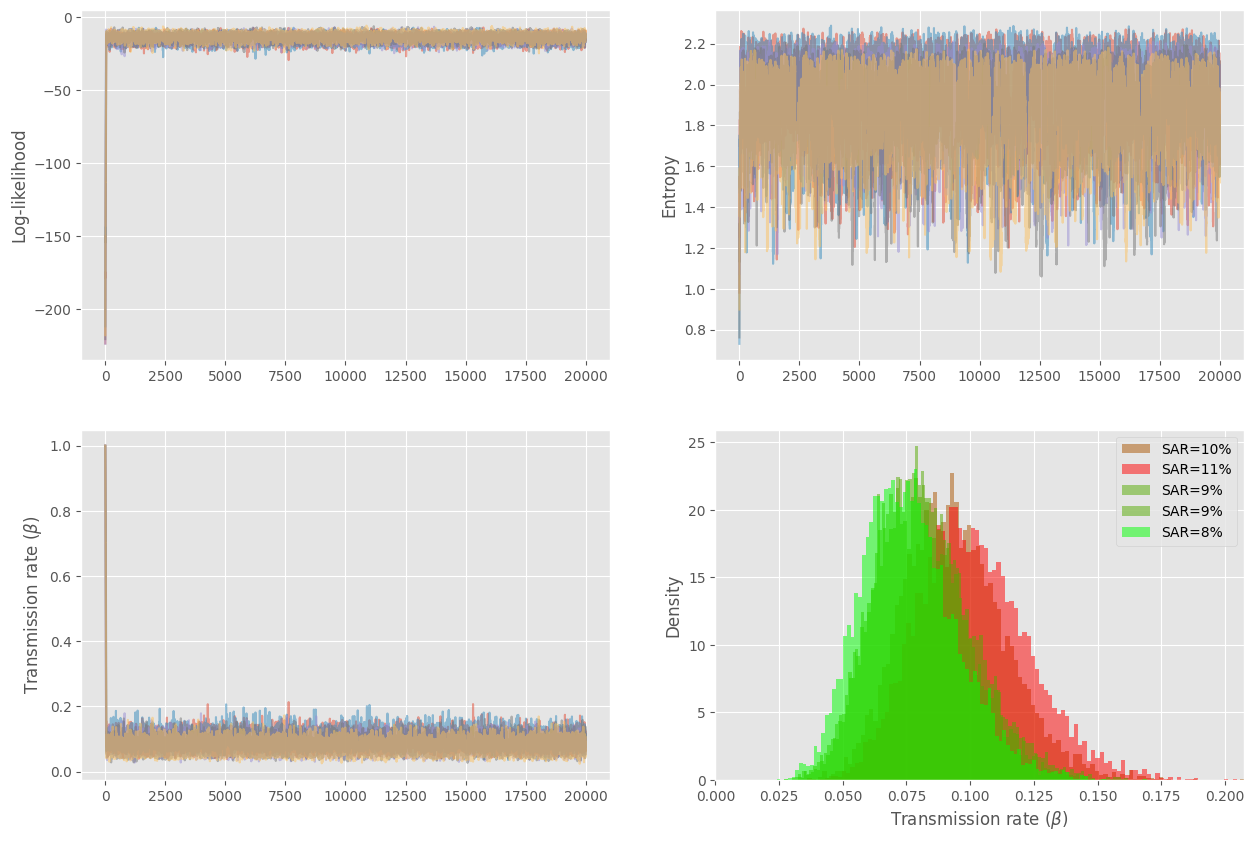

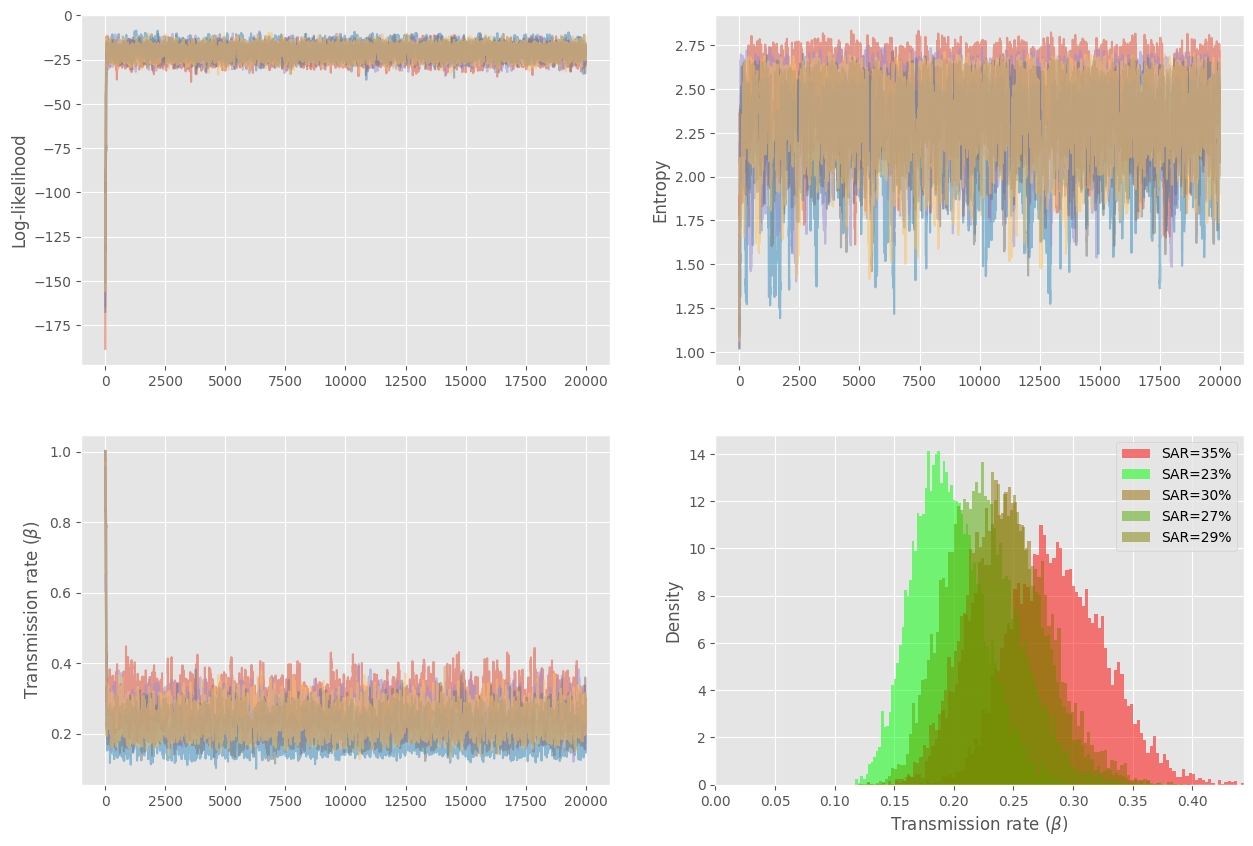

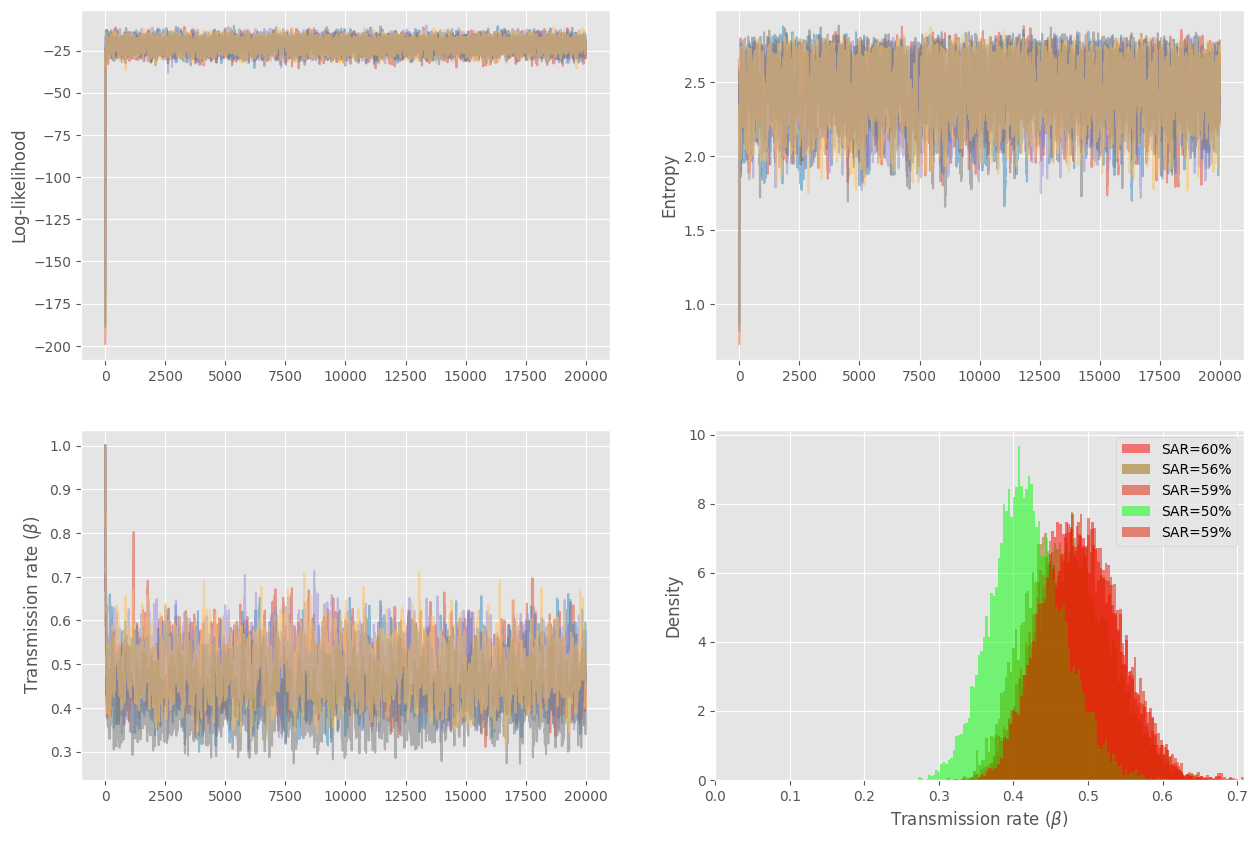

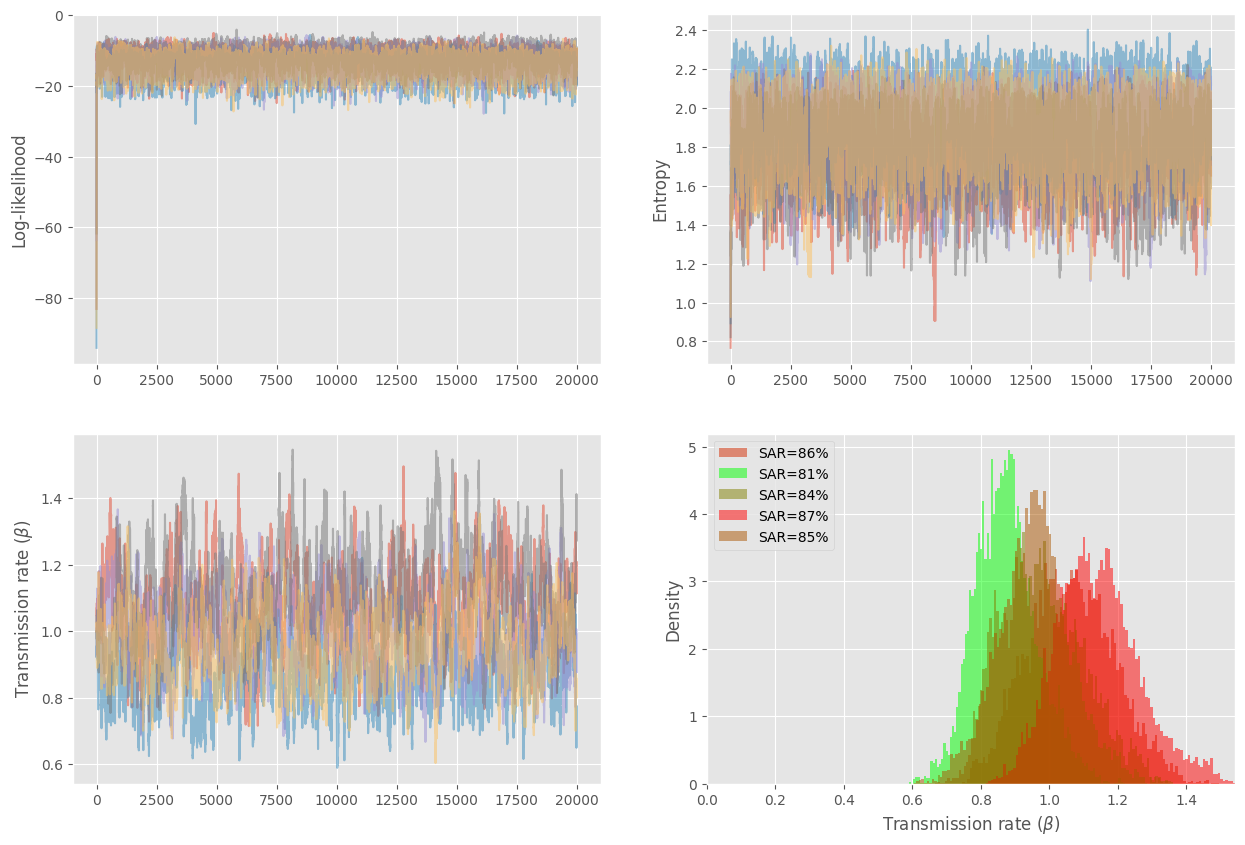

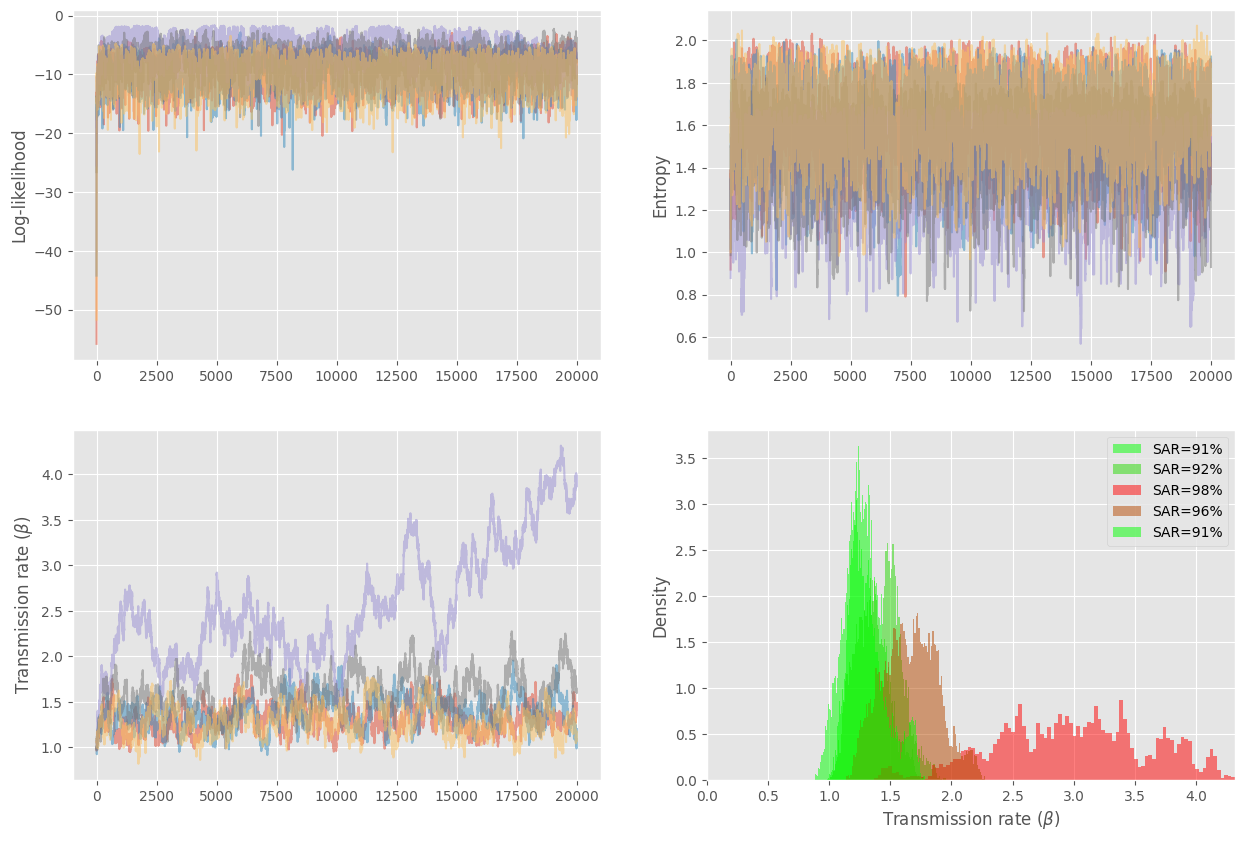

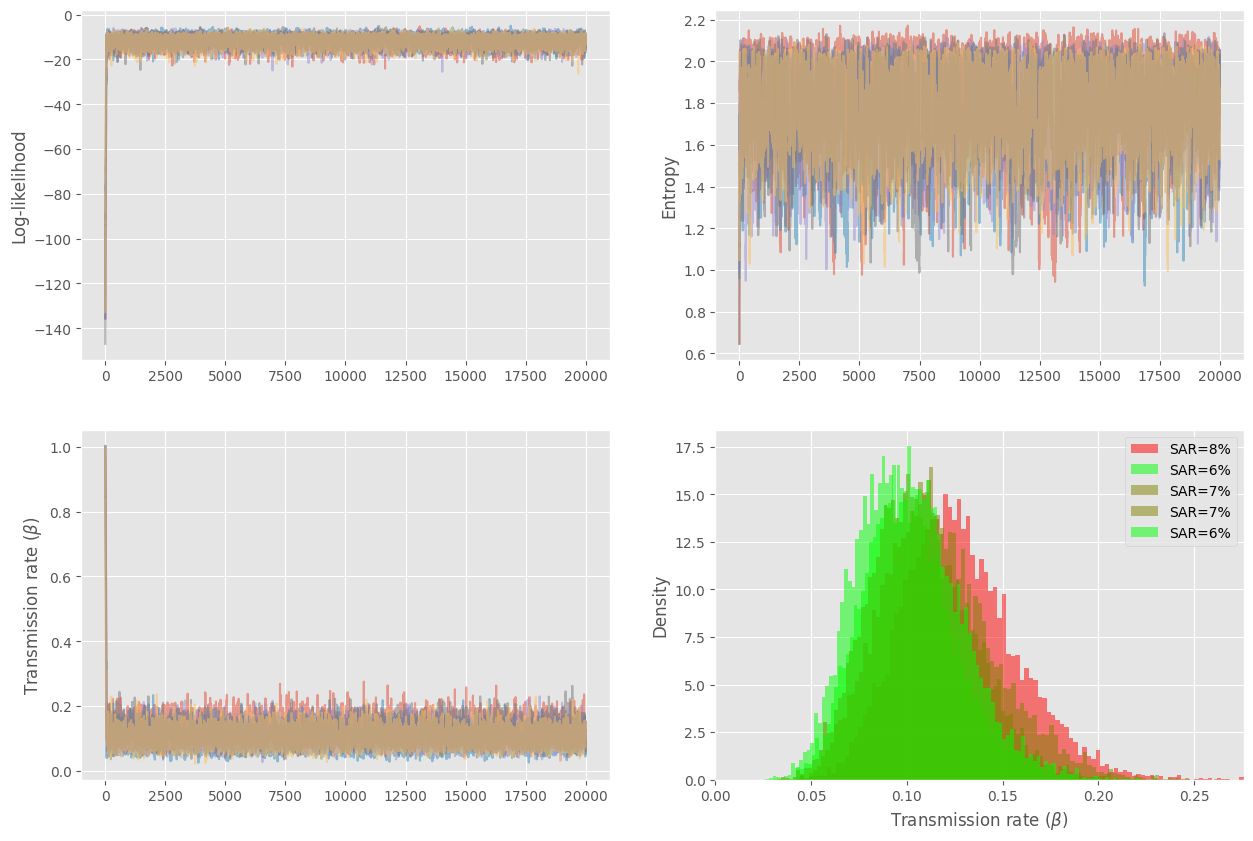

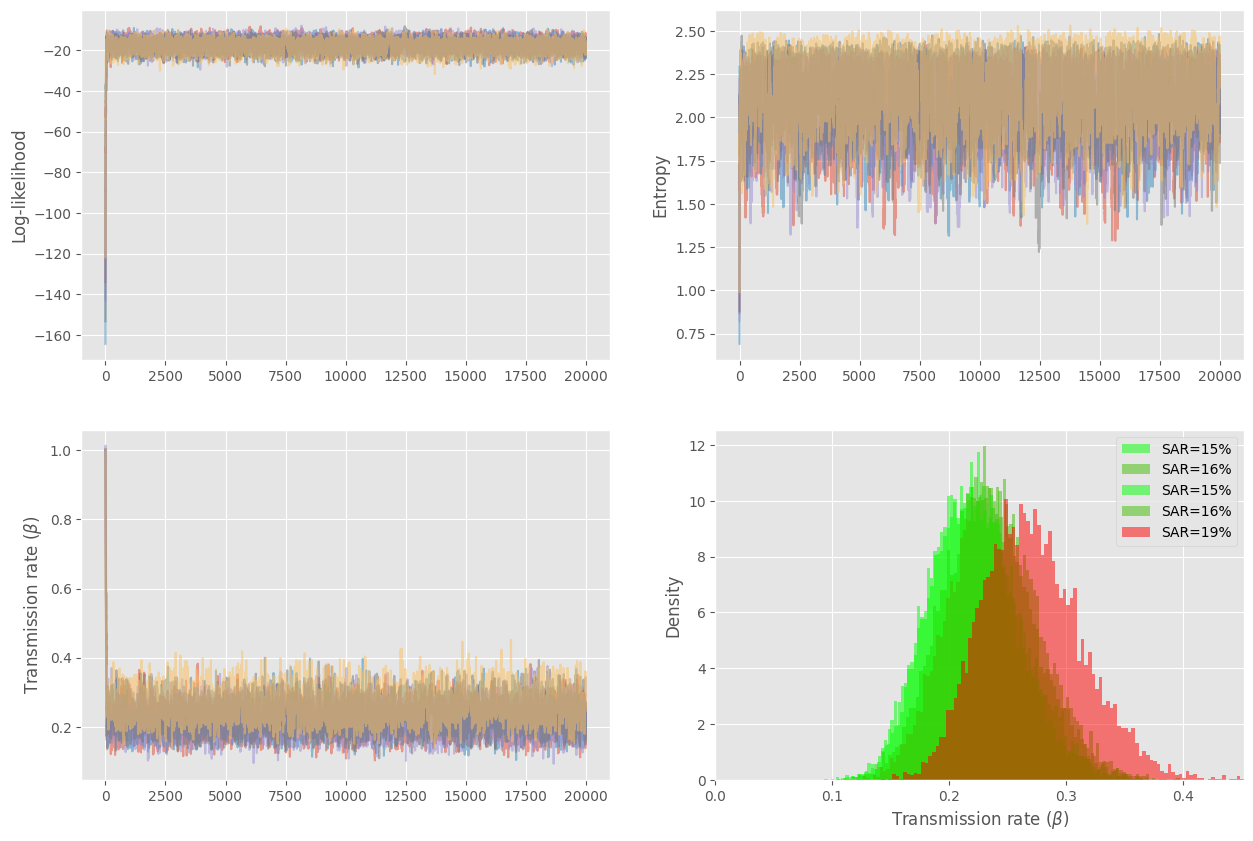

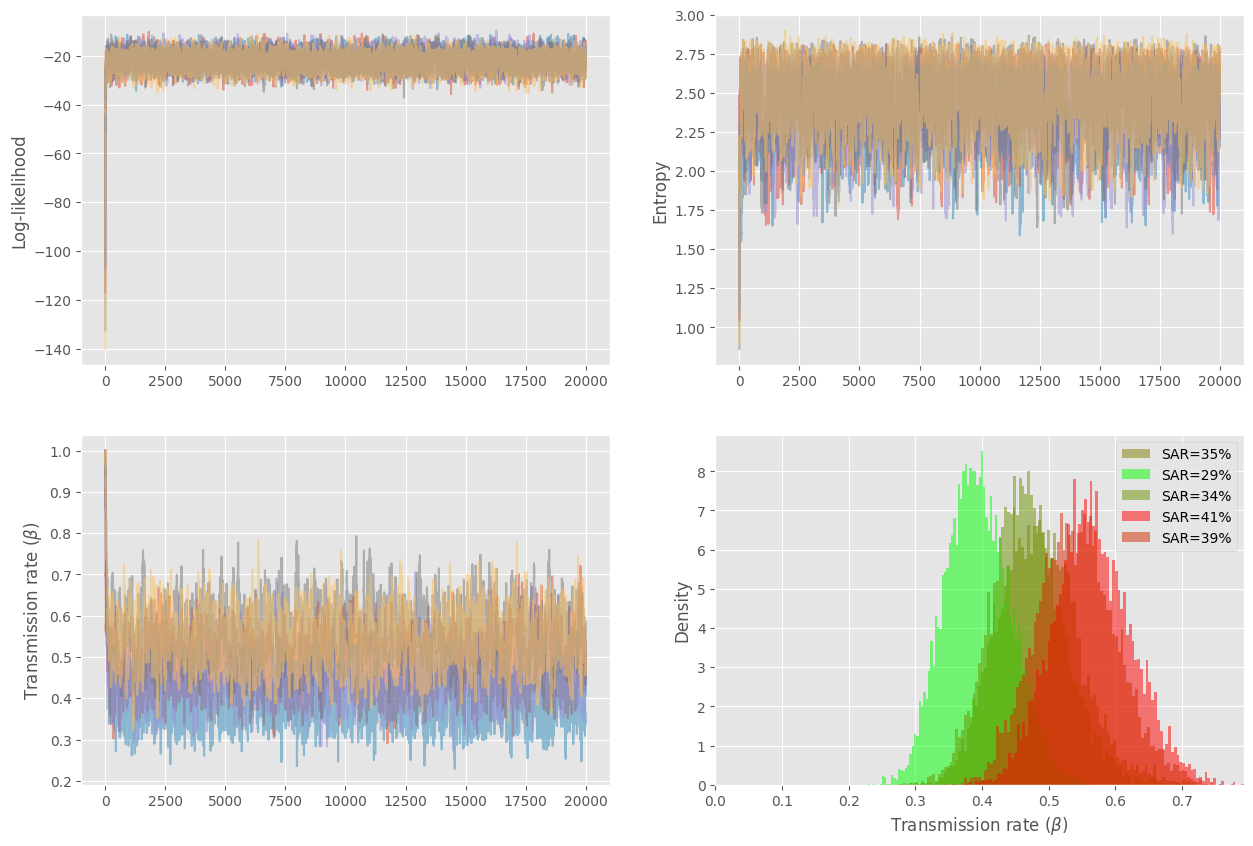

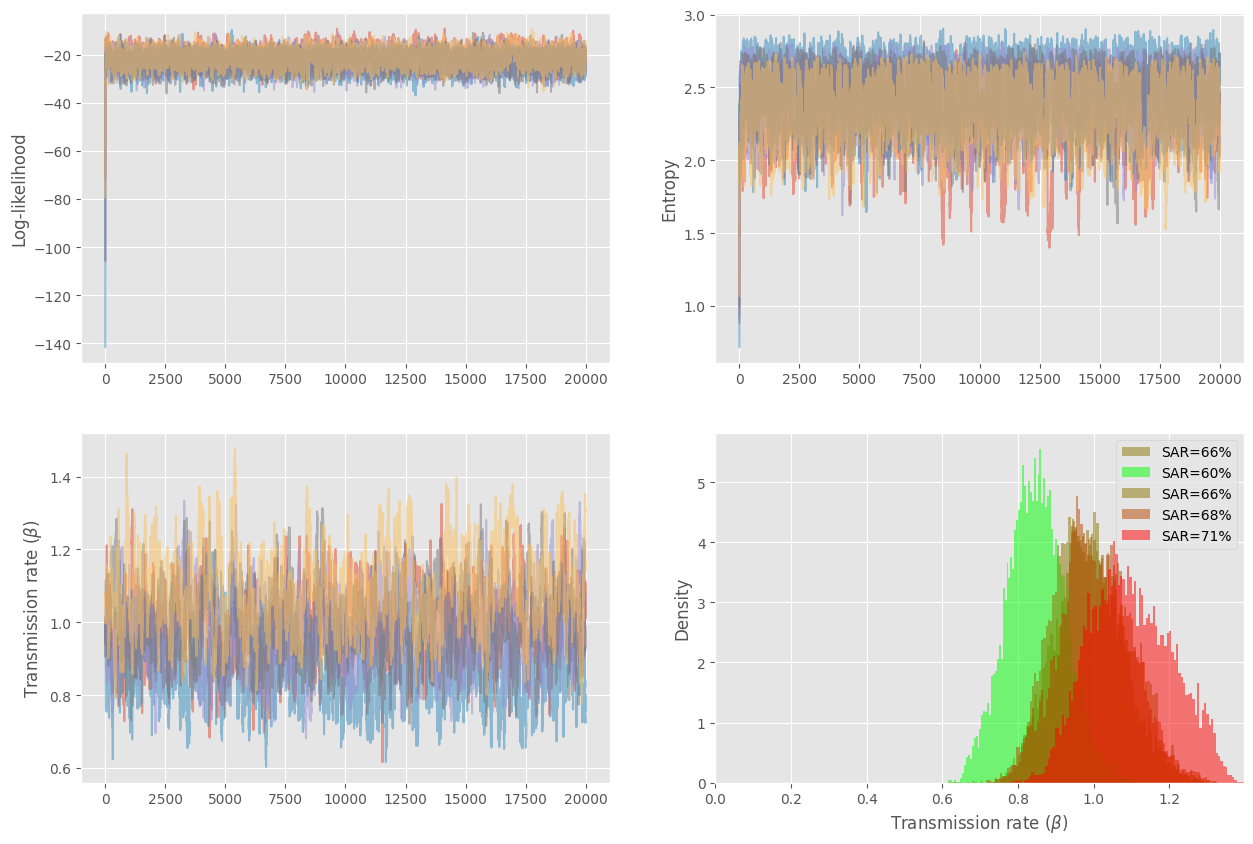

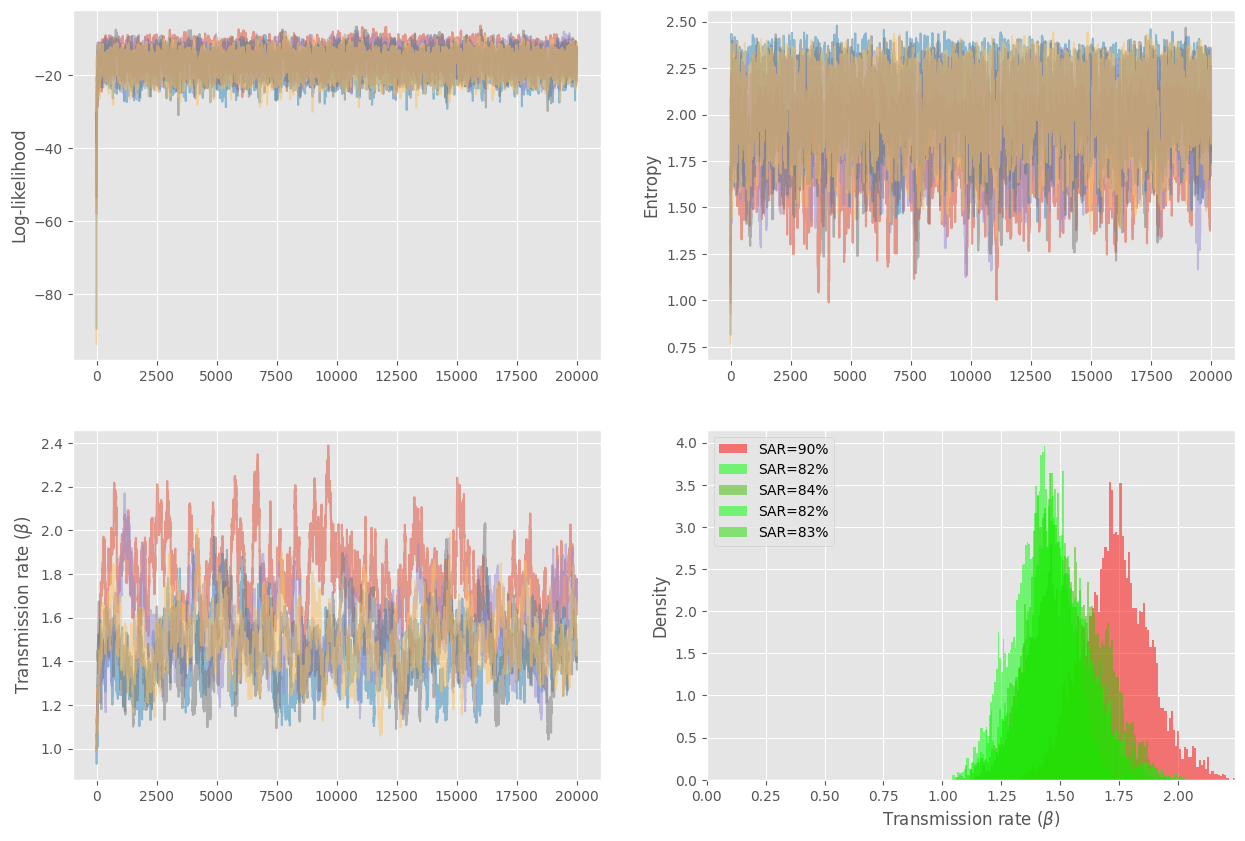

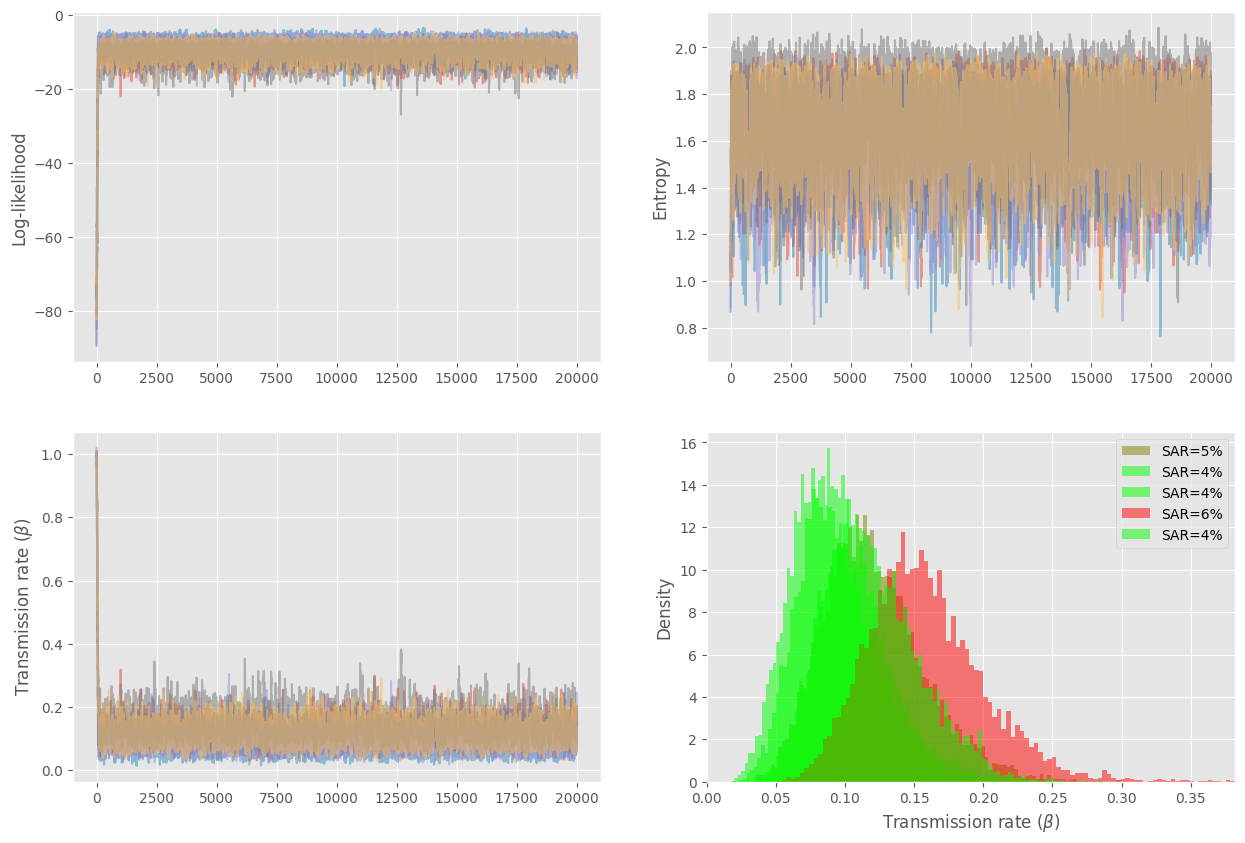

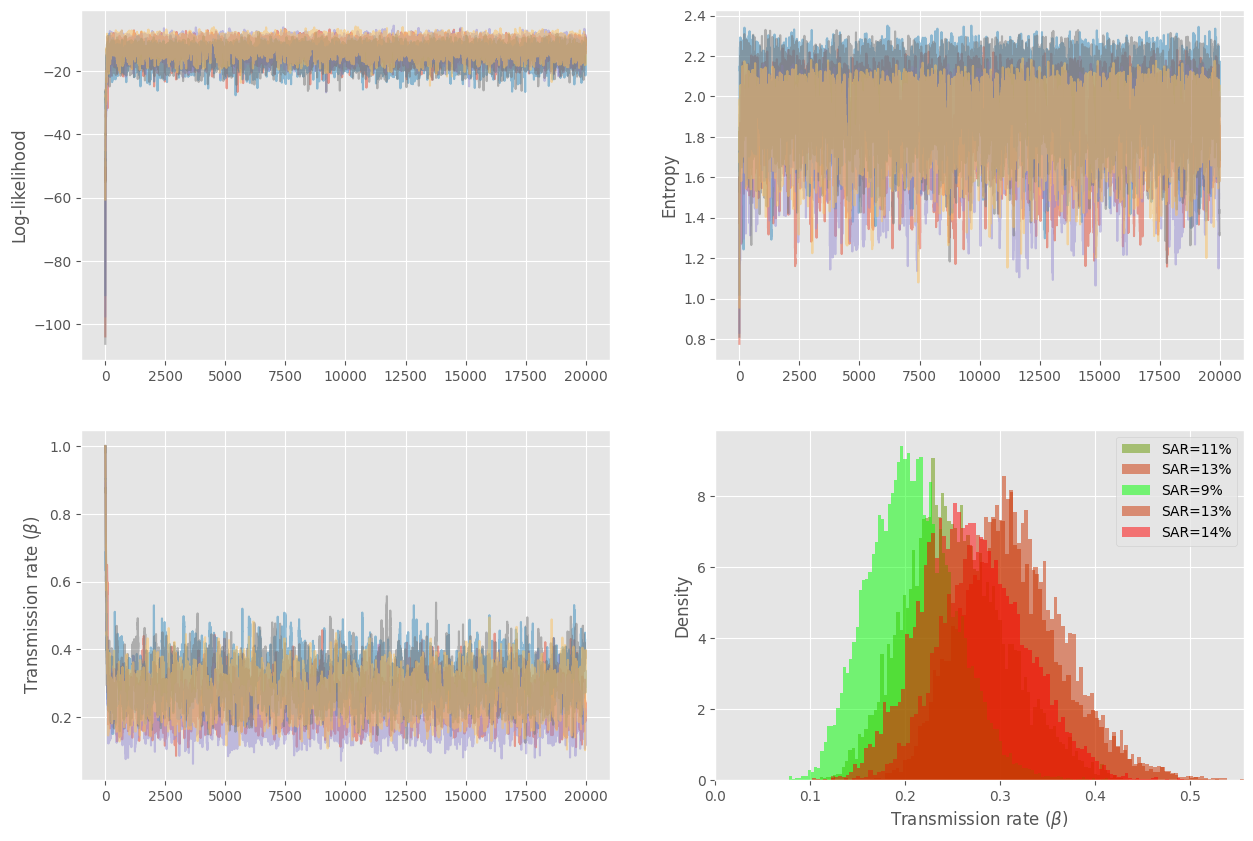

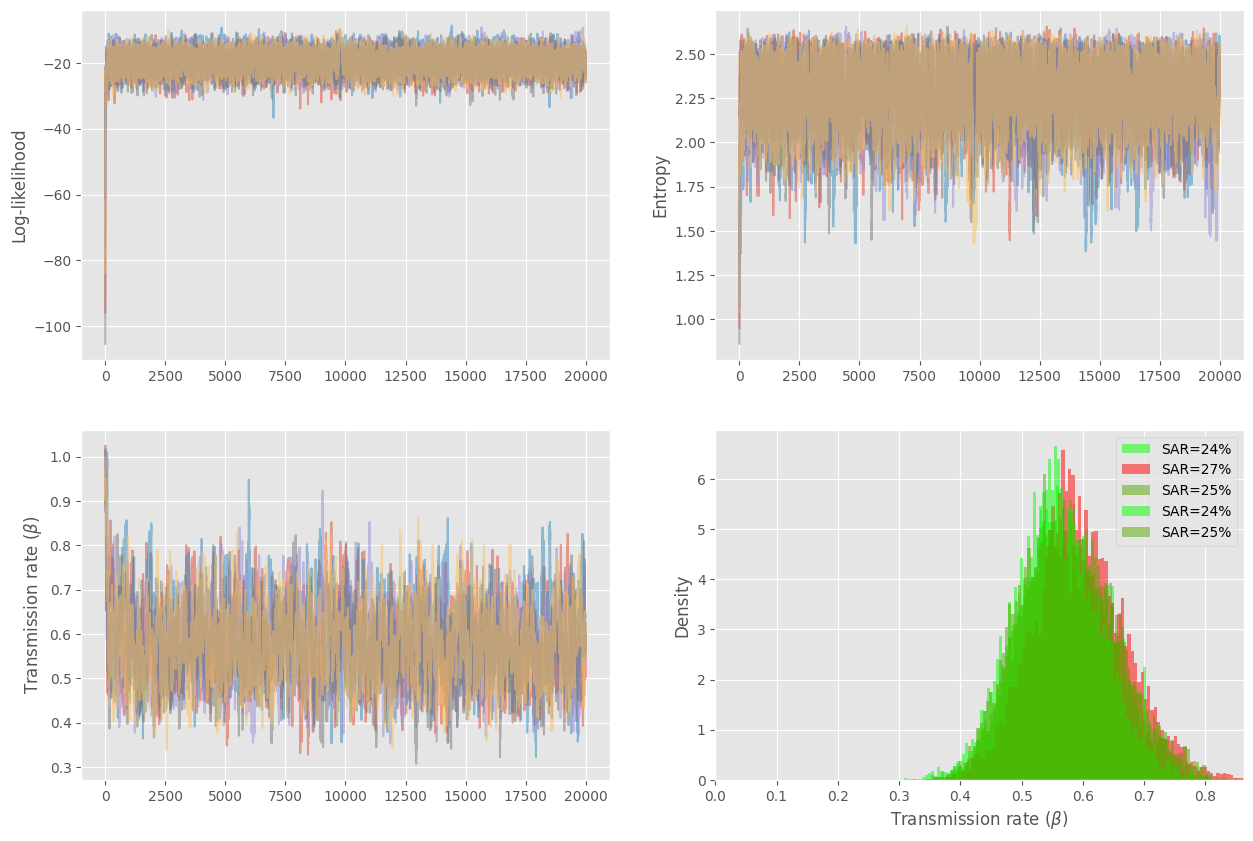

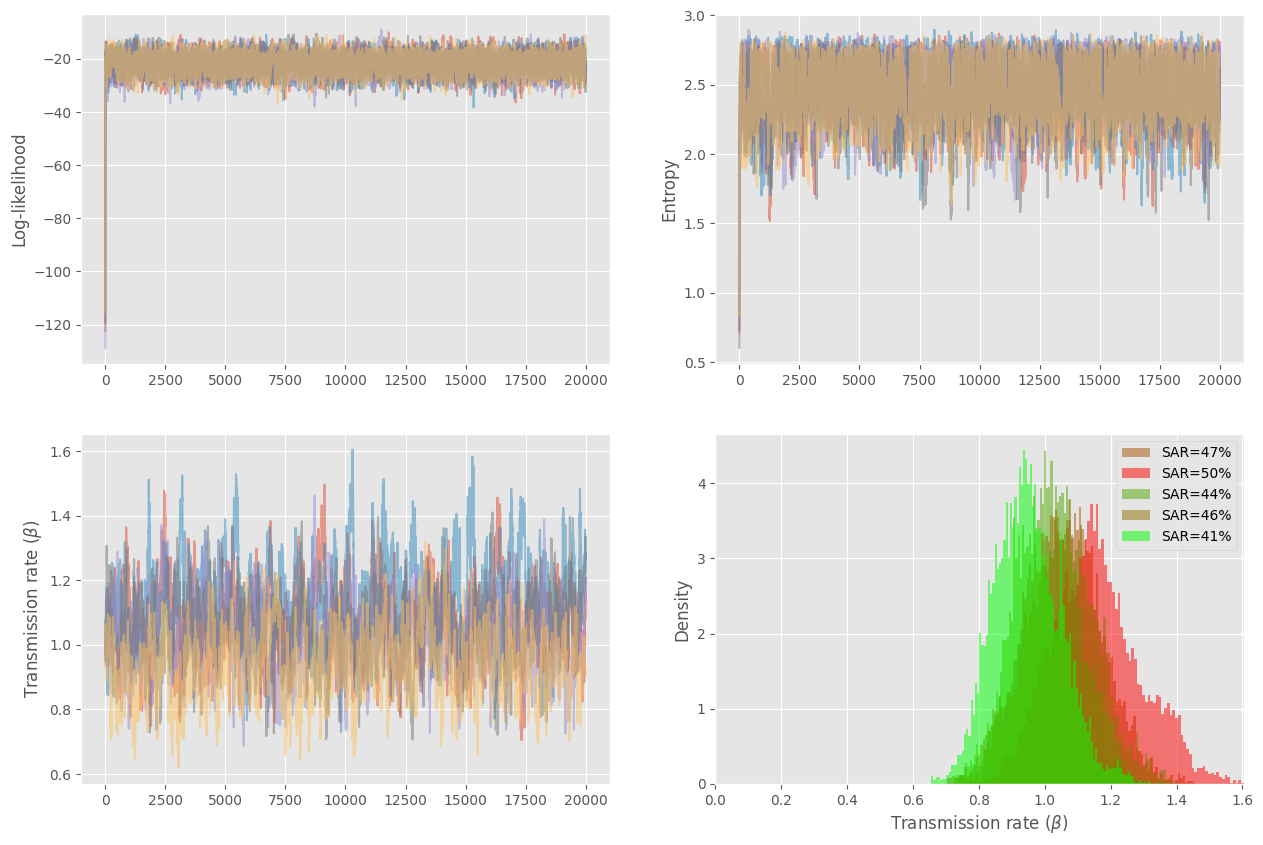

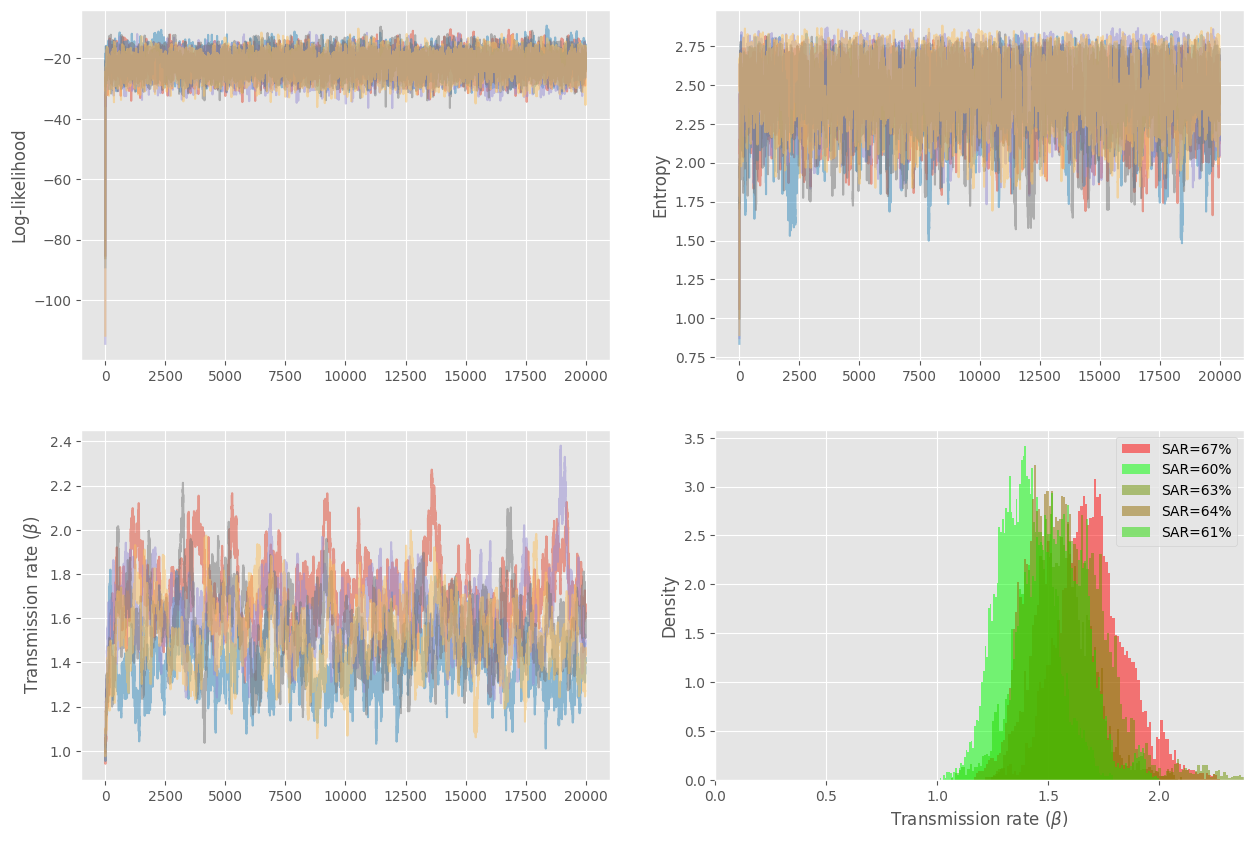

In [206]:
for eta in eta_values:
    print(eta)
    for beta in beta_values:
        print("beta = ", beta)
        filename = "testing_results/forget_start_tests/figures/flat_eta=" + str(eta) + "_beta=" + str(beta) + ".png"
        PlotResults1(results_flat_start[eta][beta],N_synthetics,KDE = False,filename = filename)
        

## Split initial partition

In [212]:
#Check if results pickle files exist or need to be generated
results_split_start = {}
for eta in eta_values:
    print("eta = ", eta)
    results_split_start[eta] = {}
    for beta in beta_values:
        print("beta = ", beta)
        filename = "testing_results/forget_start_tests/split_partition_results_eta=" + str(eta) + "_beta=" + str(beta) + ".pkl"


        if os.path.exists(filename):
            print("File found, loading results")
            with open(filename,"rb") as f:
                results_split_start[eta][beta] = load(f)
        else:
            print("File not found, generating results")
            n_iters = int(2e6)
            thin = 100
                
            results_split_start_eta_beta = {"C": np.zeros((N_synthetics,1+n_iters//thin,int(0.5*m*(m+3)))),
                                        "llhs": np.zeros((N_synthetics,1+n_iters//thin)),
                                        "beta": np.zeros((N_synthetics,1+n_iters//thin)),
                                        "entropies": np.zeros((N_synthetics,1+n_iters//thin)),
                                        "chosen_indices": np.zeros((N_synthetics,(n_iters//thin),2),dtype=int)}
            for ds in range(N_synthetics):
                N, n, y = low_info_datasets["UK"][eta][beta][ds]
                C0_split = SplitPartition(n,y,N,m)

                (results_split_start_eta_beta["C"][ds], 
                results_split_start_eta_beta["llhs"][ds], 
                results_split_start_eta_beta["beta"][ds], _, _, 
                results_split_start_eta_beta["entropies"][ds],
                results_split_start_eta_beta["chosen_indices"][ds]) = RunPartitionsMCMC(C0_split, 1, m, n_iters, 0.01, n_moves=10, verbose=True,thin =thin,eta = eta)
            with open("testing_results/forget_start_tests/split_partition_results_eta=" + str(eta) + "_beta=" + str(beta) + ".pkl","wb") as f:
                dump(results_split_start_eta_beta,f)
            results_split_start[eta][beta] = results_split_start_eta_beta

eta =  0
beta =  0.1
File found, loading results
beta =  0.25
File found, loading results
beta =  0.5
File found, loading results
beta =  1
File found, loading results
beta =  1.5
File found, loading results
eta =  0.5
beta =  0.1
File found, loading results
beta =  0.25
File found, loading results
beta =  0.5
File found, loading results
beta =  1
File found, loading results
beta =  1.5
File found, loading results
eta =  1
beta =  0.1
File not found, generating results


Running MCMC: 100%|██████████| 2000000/2000000 [08:41<00:00, 3832.46it/s]


beta =  0.25
File not found, generating results


Running MCMC: 100%|██████████| 2000000/2000000 [08:19<00:00, 4002.21it/s]


beta =  0.5
File not found, generating results


Running MCMC: 100%|██████████| 2000000/2000000 [08:07<00:00, 4100.50it/s]


beta =  1
File not found, generating results


Running MCMC: 100%|██████████| 2000000/2000000 [09:05<00:00, 3666.51it/s]


beta =  1.5
File not found, generating results


Running MCMC: 100%|██████████| 2000000/2000000 [08:03<00:00, 4135.75it/s]


0
beta =  0.1
beta =  0.25
beta =  0.5
beta =  1
beta =  1.5
0.5
beta =  0.1
beta =  0.25
beta =  0.5
beta =  1
beta =  1.5


KeyError: 1.5

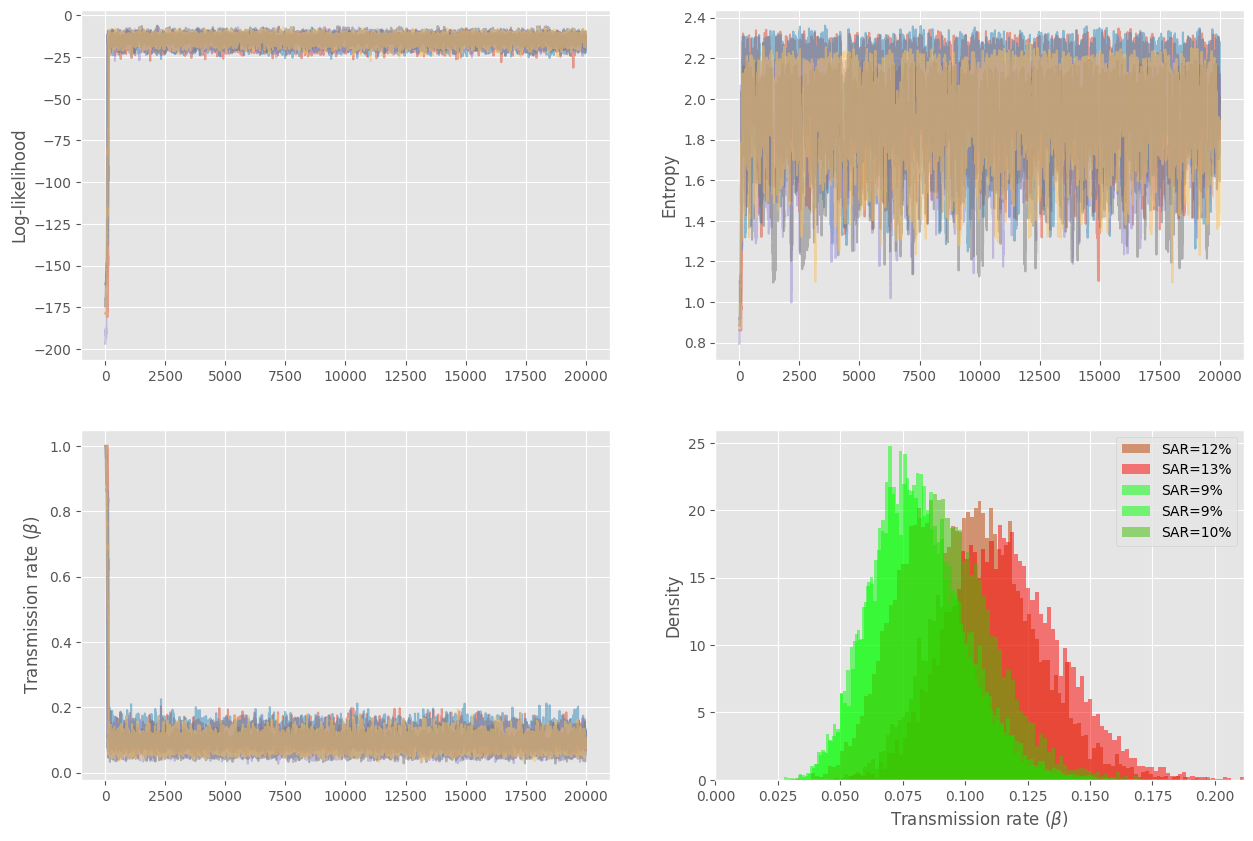

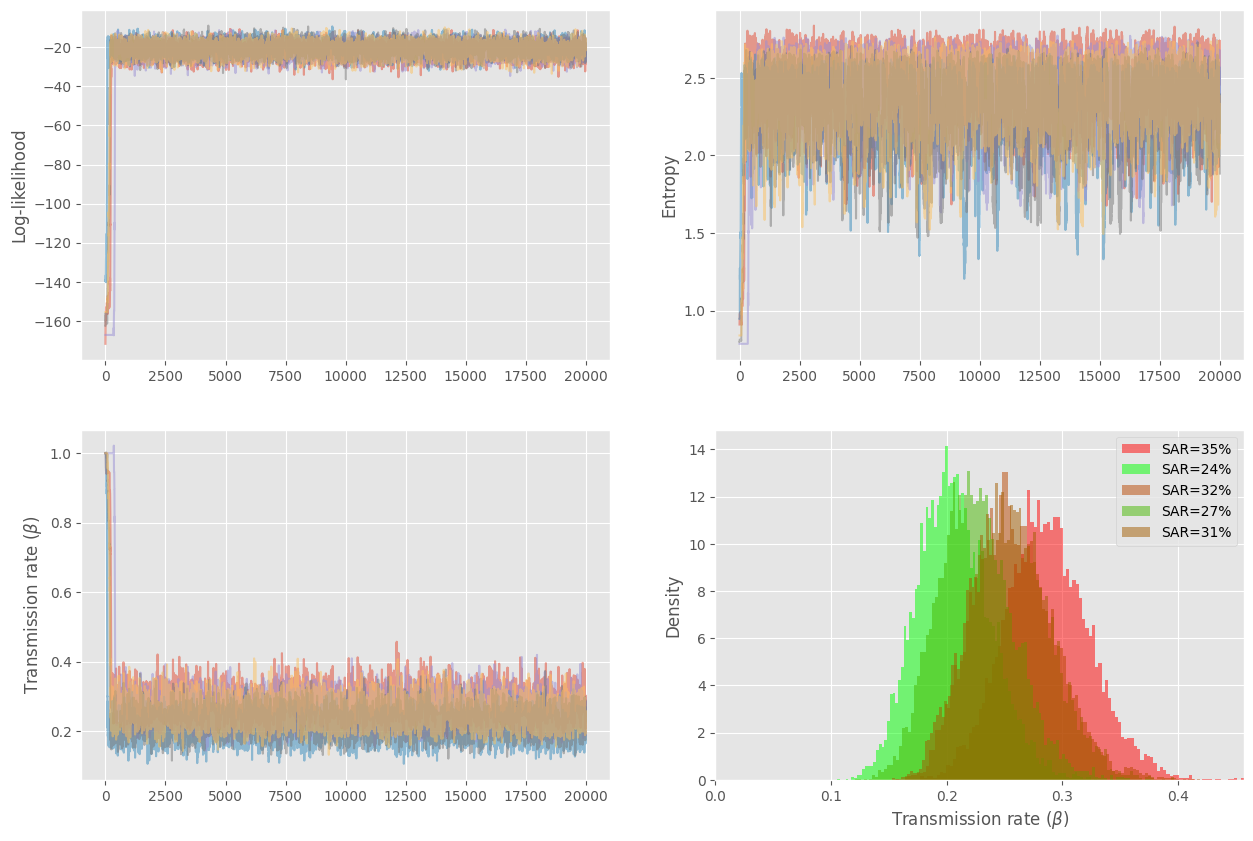

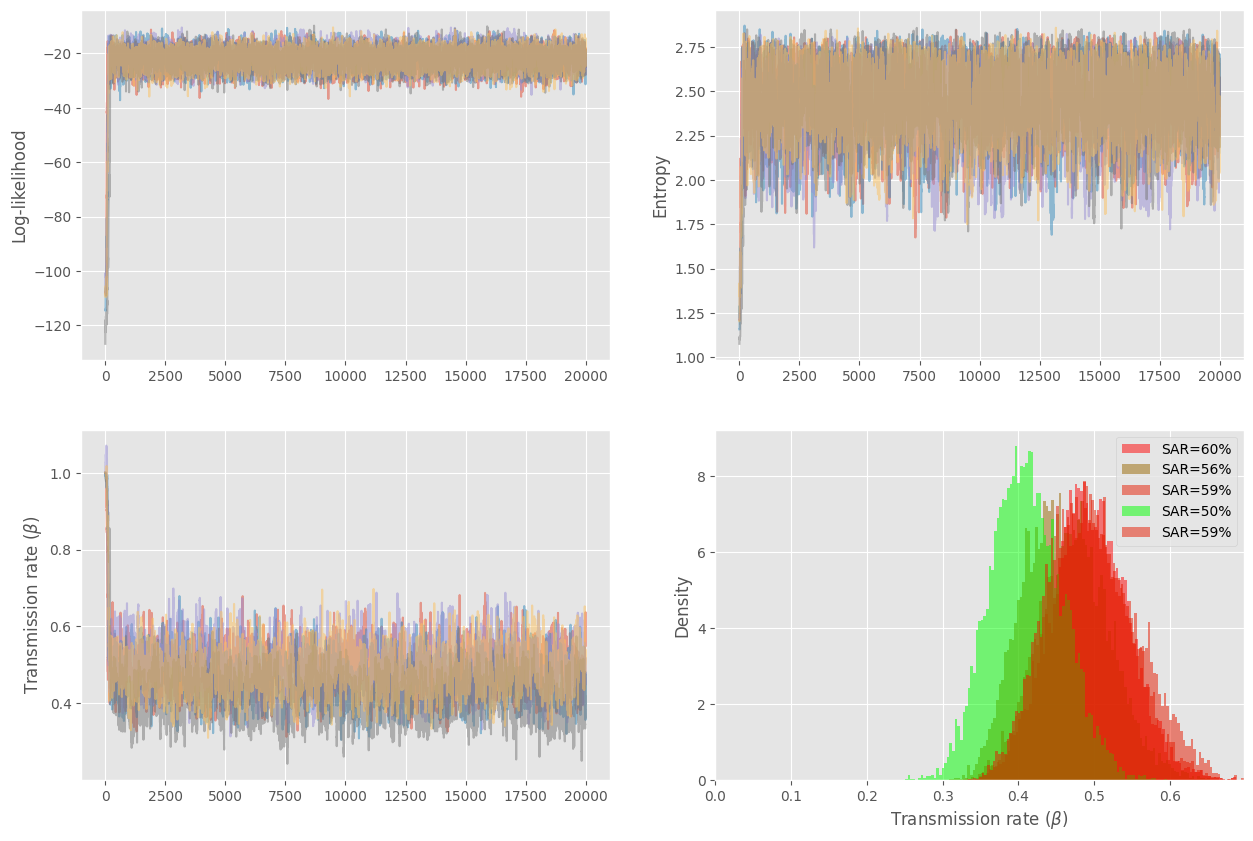

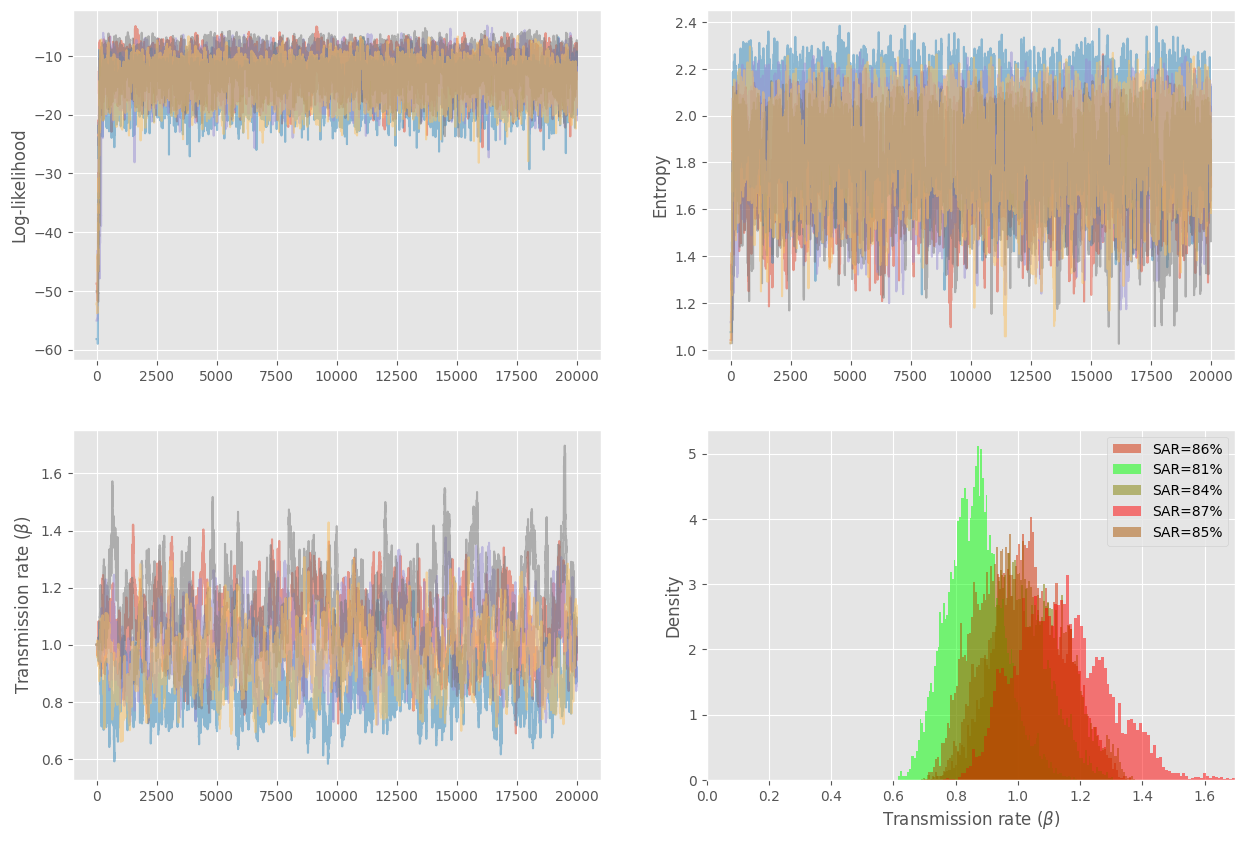

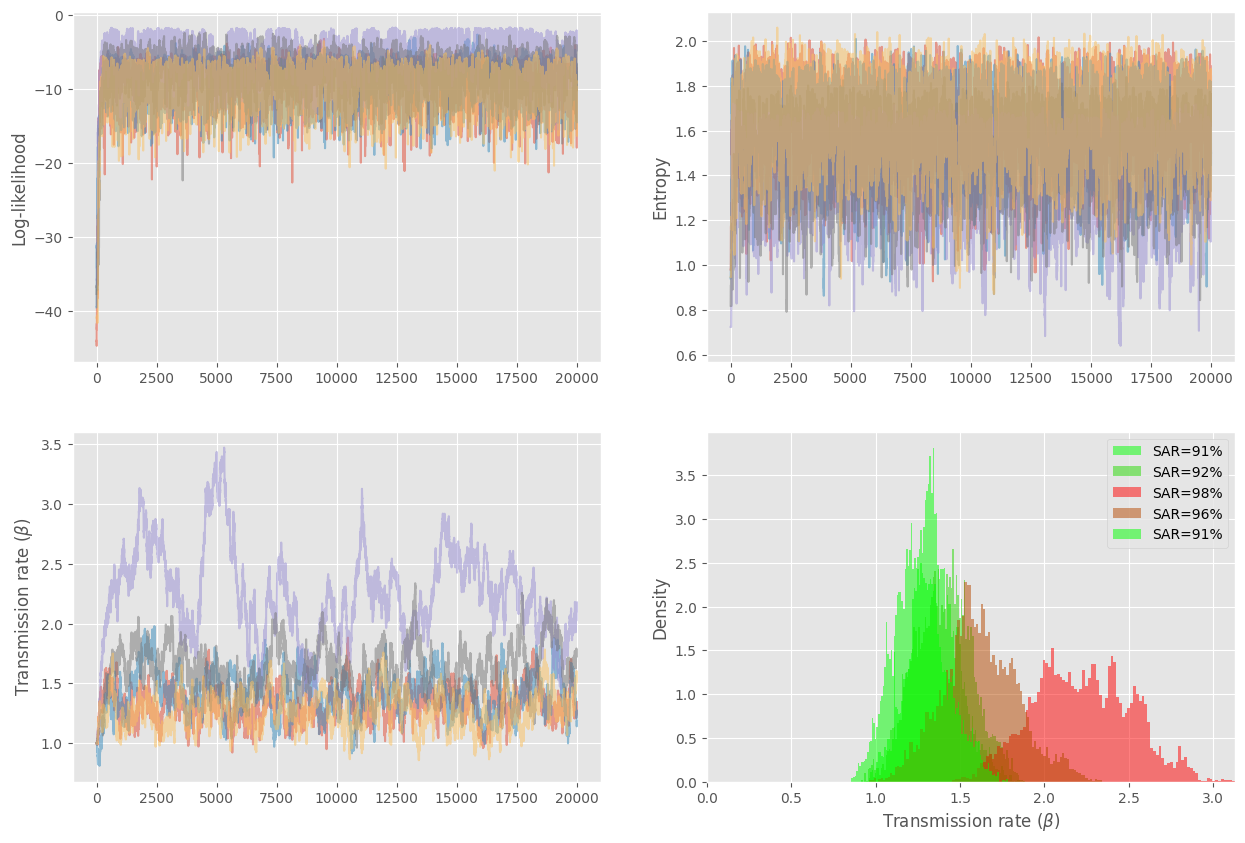

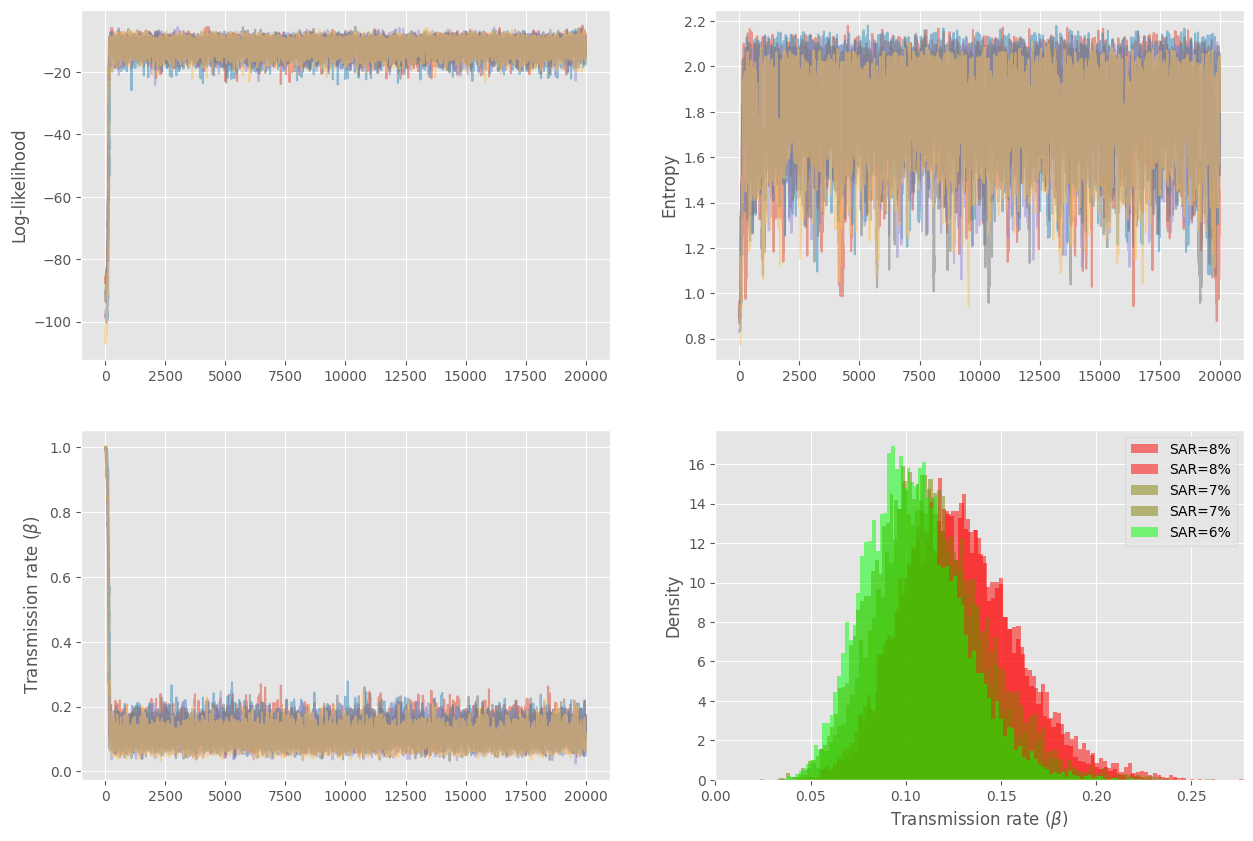

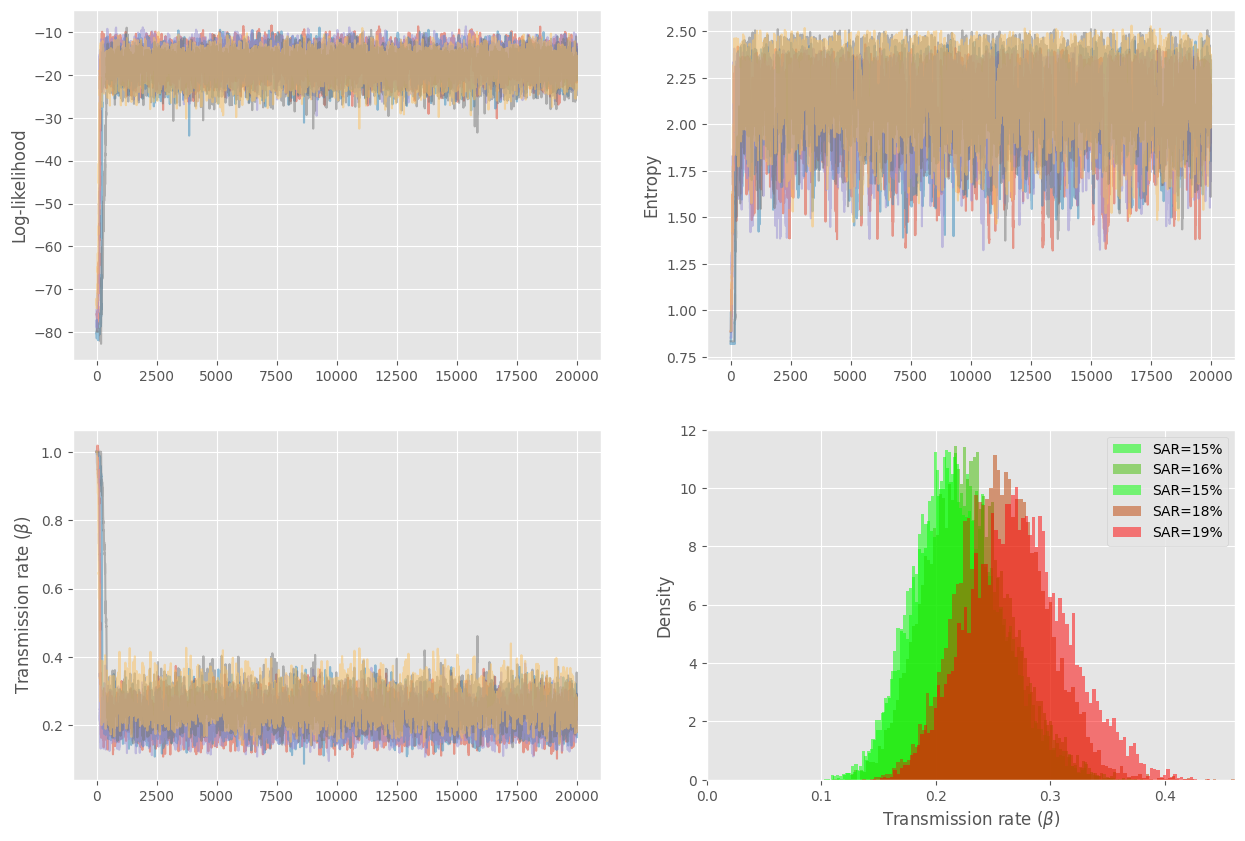

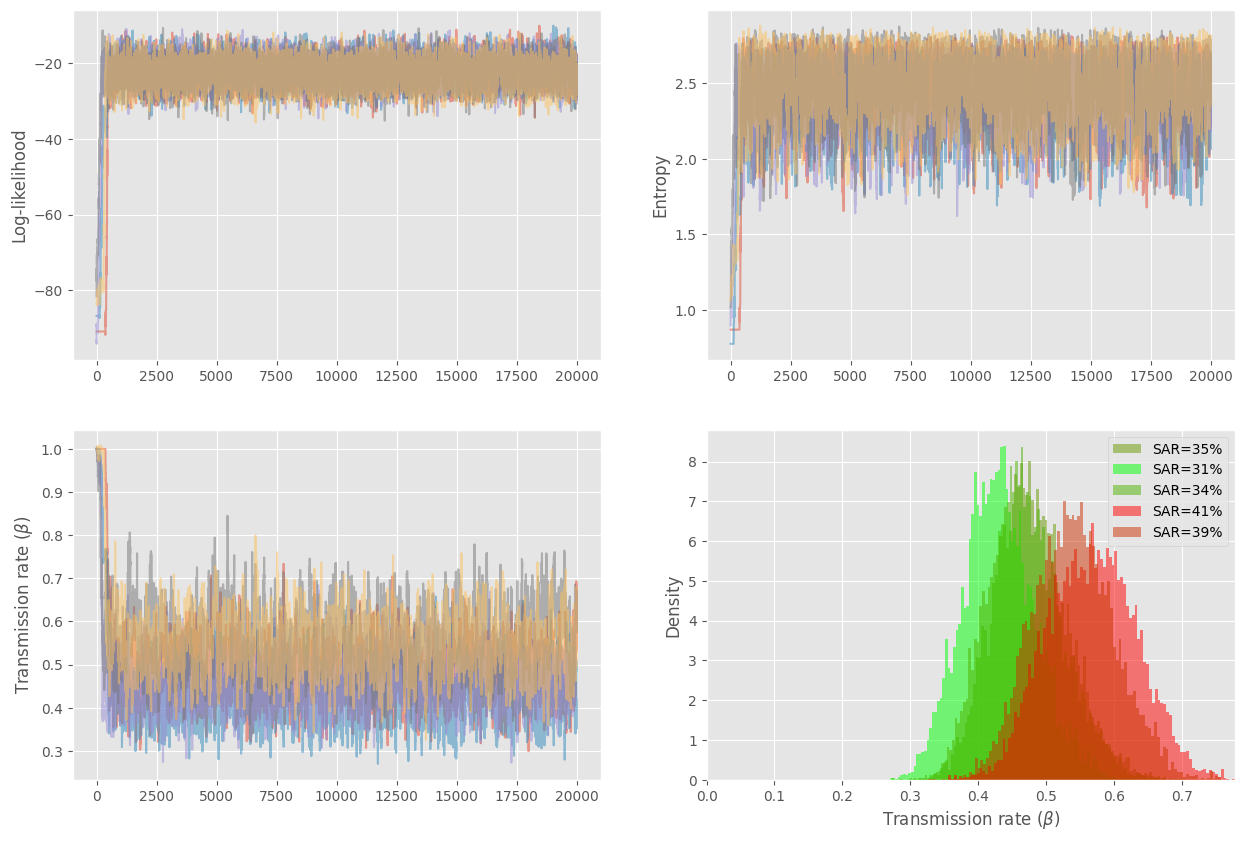

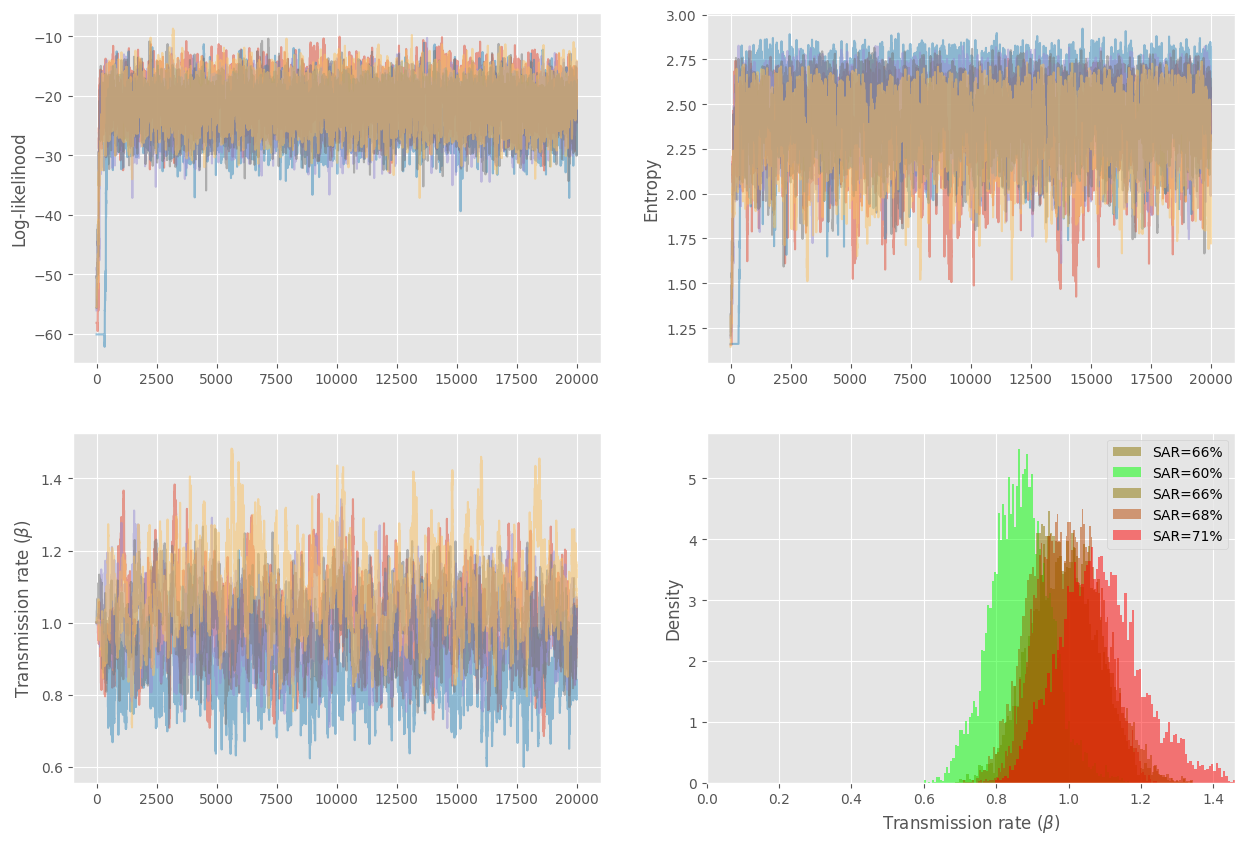

In [210]:
for eta in eta_values:
    print(eta)
    for beta in beta_values:
        print("beta = ", beta)
        filename = "testing_results/forget_start_tests/figures/split_eta=" + str(eta) + "_beta=" + str(beta) + ".png"
        PlotResults1(results_split_start[eta][beta],N_synthetics,KDE = False,filename = filename)
        

# Test 2: Moments of partitions

This test checks whether the household size distributions produced by the MCMC are similar to those in the original (unseen) data.

In [21]:
N_synthetics = 5

In [34]:
m=5
dot_for_contacts = np.concatenate([[i]*(i+1) for i in range(1,m+1)])
dot_for_cases = np.concatenate([np.arange(i+1) for i in range(1,m+1)])
mat_for_contacts = np.array([[dot_for_contacts[i]==(j+1) for i in range(len(dot_for_contacts))] for j in range(dot_for_contacts.max())])

def convert_to_hh_freq(C):
    hh_size_freq = mat_for_contacts.dot(C.T).T
    n_particles,_ = C.shape
    N = int(sum(C[0]))
    size_lists = np.zeros((n_particles,N))

    for i in range(n_particles):
        sizes = np.repeat(np.arange(1, hh_size_freq.shape[1] + 1), hh_size_freq[i].astype(int))
        size_lists[i, :len(sizes)] = sizes
    return size_lists

def PlotPartitionMoments(single_chain_data,high_info_data):
    size_lists = convert_to_hh_freq(single_chain_data)
    true_sizes = convert_to_hh_freq(high_info_data.reshape((1,len(high_info_data))))
    
    var_lists = np.var(size_lists,axis=1)
    true_var = np.var(true_sizes)
    
    skew_lists = skew(size_lists,axis=1)
    true_skew = skew(true_sizes,axis=1)
    
    kurtosis_lists = kurtosis(size_lists,axis=1)
    true_kurtosis = kurtosis(true_sizes,axis=1)

    fig,ax = plt.subplots(1,3,figsize = (15,5),sharey=True)
    fig.suptitle("Moments of the accepted partitions",fontsize = 30)
    fig.tight_layout()
    ax[0].hist(var_lists,density = True,bins = 50)
    ax[0].vlines([true_var],-1000,1000,color = "black", linestyle = "--")
    ax[0].set_title("Variance", fontsize = 20)

    ax[1].hist(skew_lists,density = True,bins = 100)
    ax[1].vlines([true_skew],-1000,1000,color = "black", linestyle = "--")
    ax[1].set_title("Skew", fontsize = 20)


    ax[2].hist(kurtosis_lists,density = True,bins = 100)
    ax[2].vlines([true_kurtosis],-1000,1000,color = "black", linestyle = "--",label = "True value")
    ax[2].set_title("Kurtosis", fontsize = 20)
    ax[2].set_ylim(0,2)

    fig.legend()




In [ ]:
beta = 1
for i in range(N_synthetics):
    PlotPartitionMoments(results_split_start[beta]["C"][i][len(results_split_start[beta]["C"][i])//2:,:],high_info_datasets["UK"][0][0.1][i])

NameError: name 'PlotPartitionMoments' is not defined

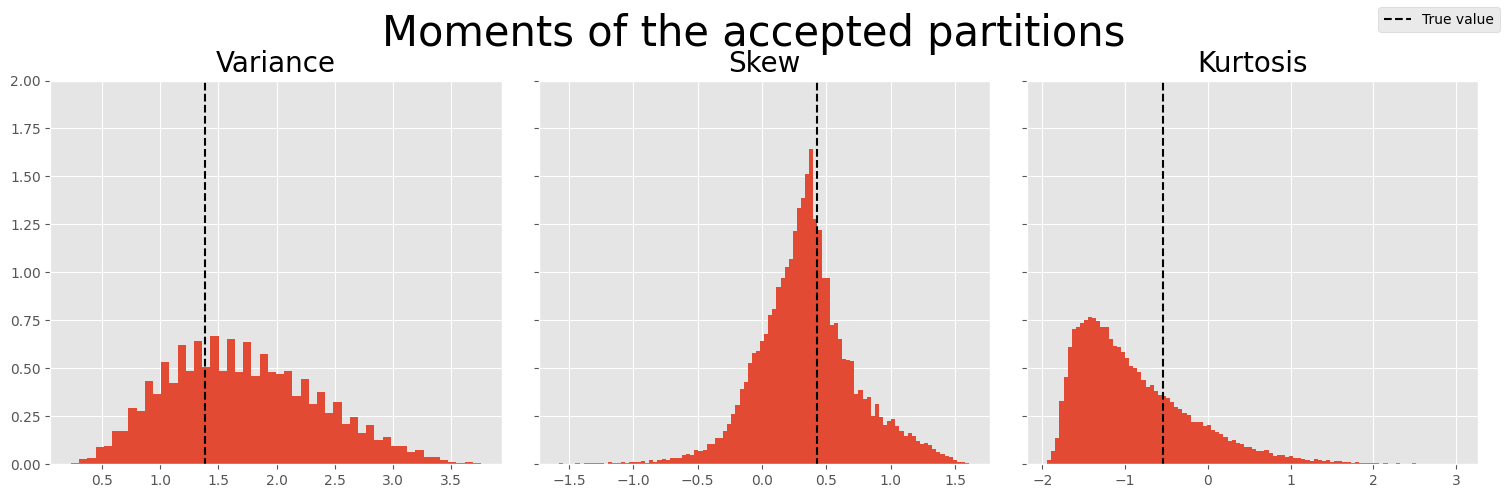

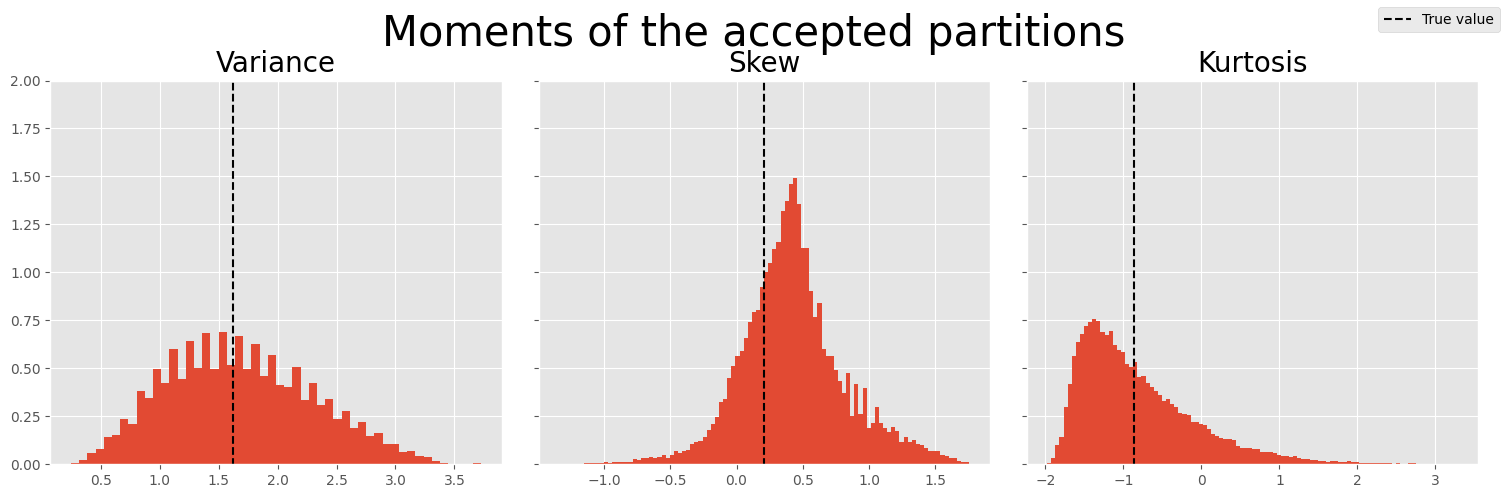

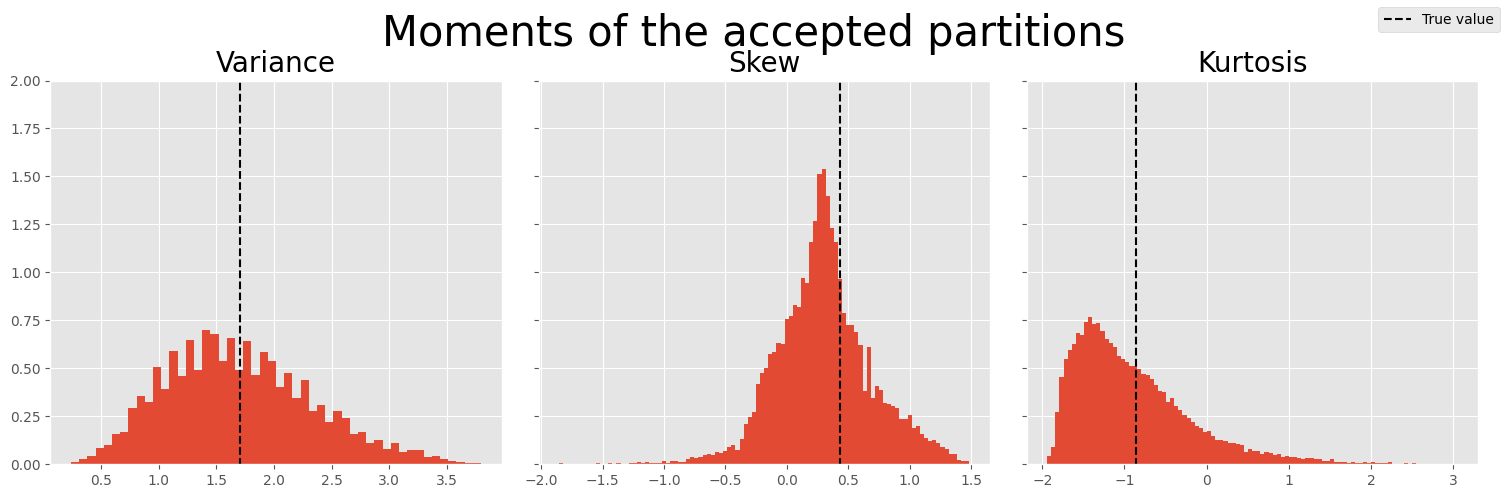

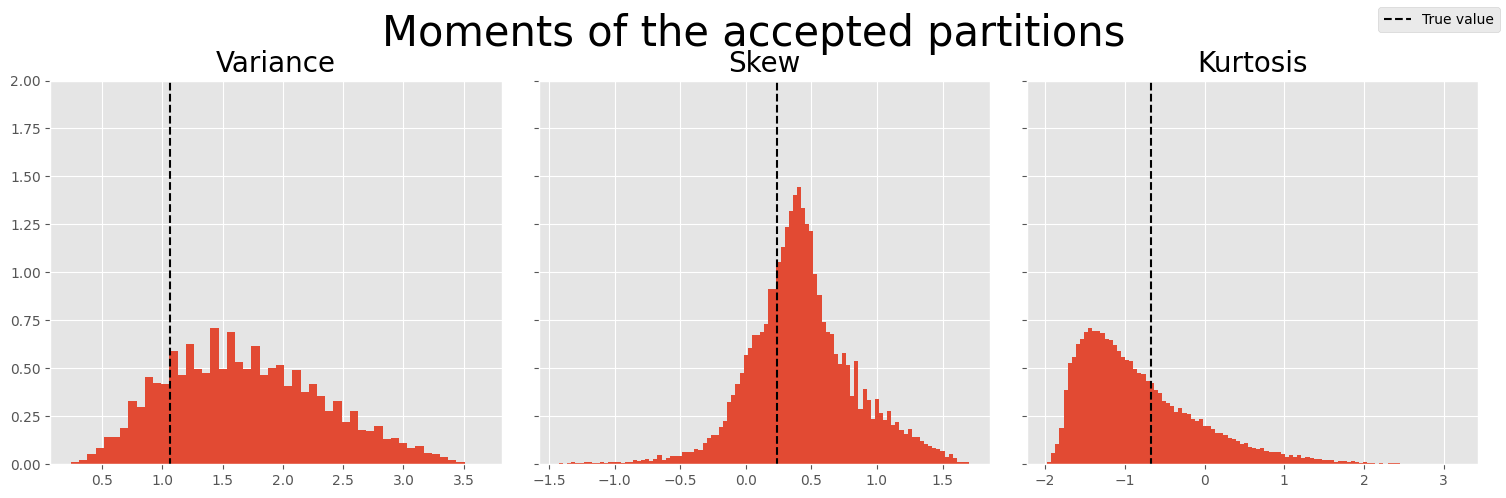

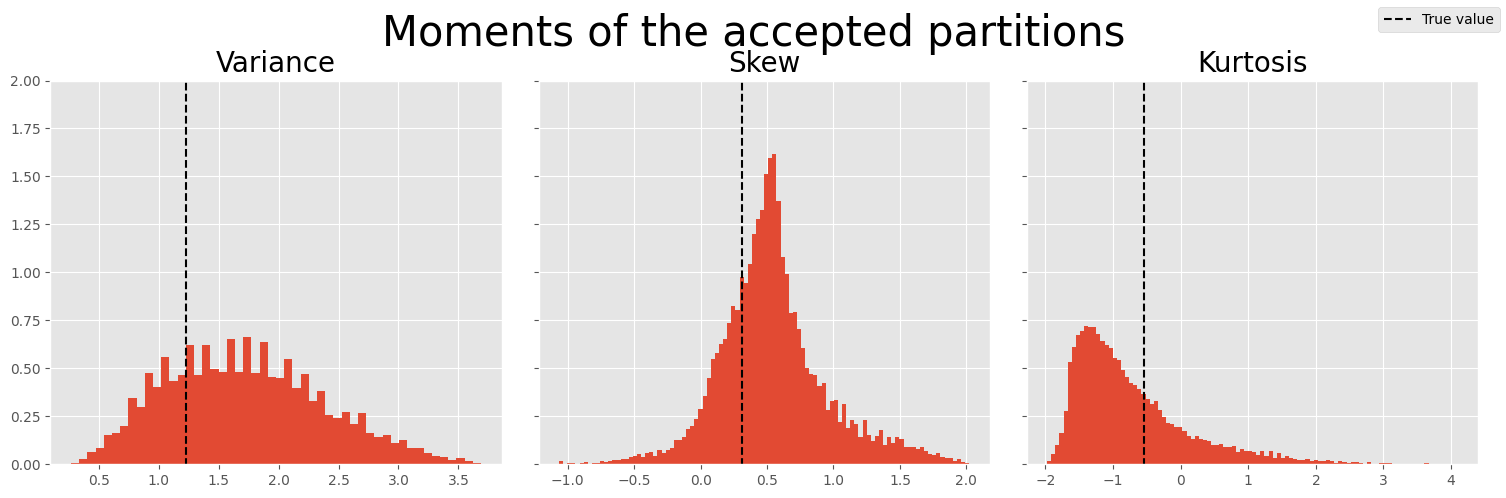

In [22]:
beta = 1
for i in range(N_synthetics):
    PlotPartitionMoments(results_flat_start[beta]["C"][i][len(results_flat_start[beta]["C"][i])//2:,:],high_info_datasets_uk[0.1][i])

# Test 3: Prior on $\beta$

In [16]:
def PlotResults3(results,mu_values,s_values,KDE=False,filename = None,no_prior_result = None):
    fig,ax = plt.subplots(figsize=(10,8))
    x_max=0
    #Log_likelihood plots
    ax.set_ylabel("Density")
    ax.set_xlabel("Transmission rate " + r"$(\beta )$")
    #ax[0,0].set_ylabel("Log-likelihood")
    #ax[1,0].set_ylabel("Transmission rate " + r"$(\beta )$")
    #ax[0,1].set_ylabel("Entropy")

    colours = [(1,0,0),(0,1,0),(0,0,1)]
    linestyles = ["-","--",":"]


    
    for i,mu in enumerate(mu_values):
        for j,s in enumerate(s_values):
       
            #ax[0,0].plot(results["llhs"][i,j],alpha=0.5)
            
            #Beta chains
            #ax[1,0].plot(results["beta"][i,j],alpha=0.5)
            
           # ax[0,1].plot(results["entropies"][i,j],alpha= 0.5)
            
            #Beta histogram

            betas = results["beta"][i,j][len(results["beta"][i,j])//2:]
            #ax[1,1].hist(betas,bins=100,density=True,color = colours[j],alpha = 0.5,label = "N(" + str(mu)+ ","+ str(s) +")")
            x_max = max(max(betas),x_max)
            
            #CI = np.percentile(betas,[2.5,97.5])
            #ax[1,1].vlines(CI,0,4,linestyle="--",color = "black")
            #ax[1,1].vlines(np.mean(betas),0,6,color = "black")

            KDE = gaussian_kde(betas)
            X = np.linspace(0,x_max,1000)
            ax.plot(X,KDE(X),color=colours[i],ls=linestyles[j],label = "N(" + str(mu)+ ","+ str(s) +")")
    if no_prior_result!=None:
        betas = no_prior_result["beta"][len(no_prior_result["beta"])//2:]
        KDE = gaussian_kde(betas)
        X = np.linspace(0,x_max,1000)
        ax.plot(X,KDE(X),color="black",label = "No prior")
    ax.set_xlim(0,x_max)
    ax.legend()
    if filename != None:
        plt.savefig(filename)

In [ ]:
#Check if results pickle files exist or need to be generated
beta_values = [0.1,0.25,1.5]
m=5
s_values = [0.1,0.2,0.3]
mu_values = [0.25,0.5,0.75]
results_beta_prior = {}
for beta in beta_values:
    print("beta = ", beta)
    if os.path.exists("testing_results/beta_prior_tests/beta_prior_results_beta=" + str(beta) + ".pkl"):
        print("File found, loading results")
        with open("testing_results/beta_prior_tests/beta_prior_results_beta=" + str(beta) + ".pkl","rb") as f:
            results_beta_prior[beta] = load(f)
    else:
        print("File not found, generating results")
        n_iters = int(1e6)
        thin = 10
        results_flat_start_beta = {"C": np.zeros((3,3,1+n_iters//thin,int(0.5*m*(m+3)))),
                                    "llhs": np.zeros((3,3,1+n_iters//thin)),
                                    "beta": np.zeros((3,3,1+n_iters//thin)),
                                    "entropies": np.zeros((3,3,1+n_iters//thin)),
                                    "chosen_indices": np.zeros((3,3,(n_iters//thin),2),dtype=int)}
        for i,mu in enumerate(mu_values):
            for j,s in enumerate(s_values):
                print("N(" + str(mu)+ ","+ str(s) +")")
                beta_prior = norm(mu,s).logpdf

        
                N, n, y = low_info_datasets_uk[beta][0]
                C0_flat = FlatPartition(n,y,N,m)

                (results_flat_start_beta["C"][i,j], 
                results_flat_start_beta["llhs"][i,j], 
                results_flat_start_beta["beta"][i,j], _, _, 
                results_flat_start_beta["entropies"][i,j],
                results_flat_start_beta["chosen_indices"][i,j]) = RunPartitionsMCMC(C0_flat, 
                                                                                    beta0=1, 
                                                                                    m=m, 
                                                                                    n_iters=n_iters, 
                                                                                    beta_proposal_sd=0.01,
                                                                                    n_moves=10,
                                                                                    beta_prior=beta_prior, 
                                                                                    verbose=True,
                                                                                    thin=thin)
                
        with open("testing_results/beta_prior_tests/beta_prior_results_beta=" + str(beta) + ".pkl","wb") as f:
            dump(results_flat_start_beta,f)
        results_beta_prior[beta] = results_flat_start_beta


beta =  0.1
File found, loading results
beta =  0.25
File found, loading results
beta =  1.5
File found, loading results


beta =  0.1
beta =  0.25
beta =  1.5


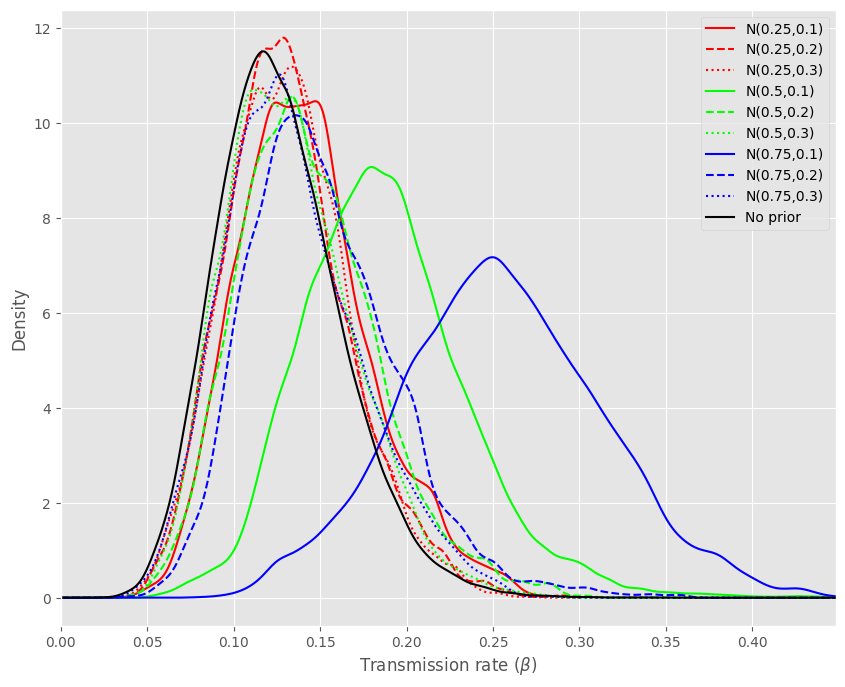

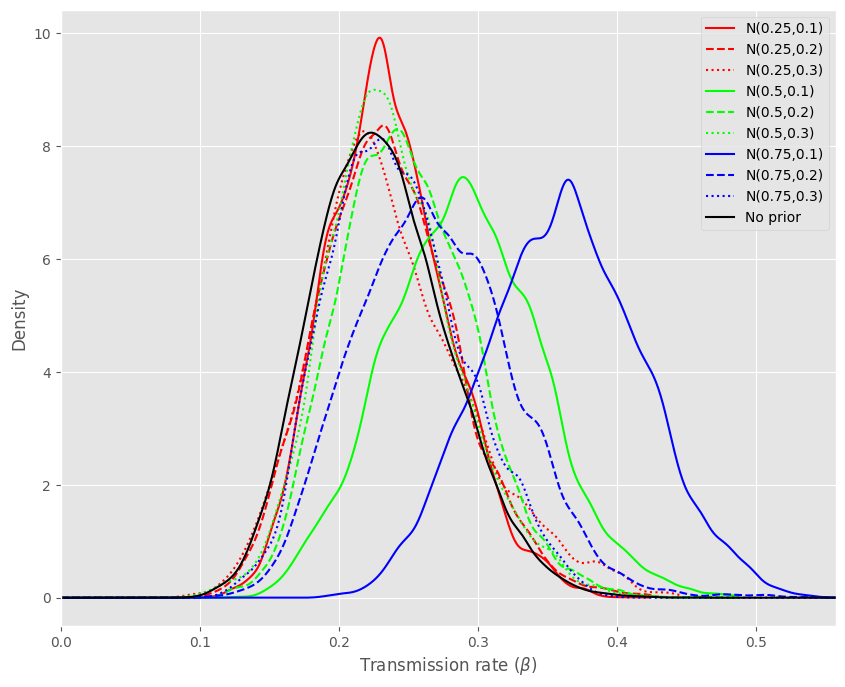

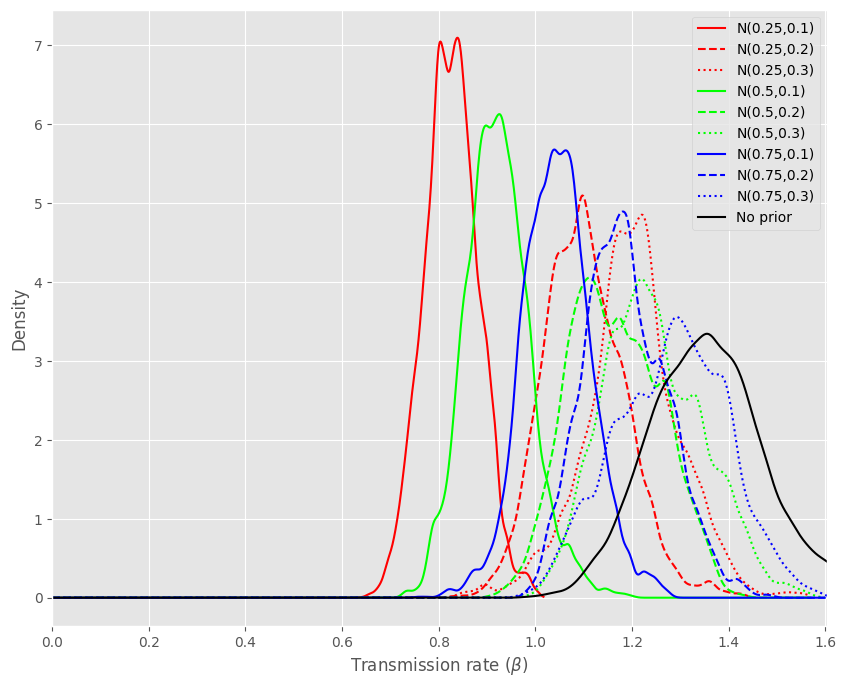

In [18]:
for beta,results in results_beta_prior.items():
    print("beta = ", beta)
    no_prior_results = {k:v[0] for k,v in results_flat_start[beta].items()}
    PlotResults3(results,mu_values,s_values,no_prior_result=no_prior_results)

# Test 4: Prior on household size distribution

In [58]:
C = results_flat_start[1]["C"][0][0]
approx_uk_prior = np.array([0.3, 0.15, 0.13, 0.13, 0.05])

approx_uk_prior = approx_uk_prior * np.arange(1, 6)
approx_uk_prior = approx_uk_prior / sum(approx_uk_prior)
print("approx_uk_prior:", approx_uk_prior)

split_prior = np.array([0.8, 0.01, 0.01, 0.01, 0.2])
split_prior = split_prior * np.arange(1, 6)
split_prior = split_prior / sum(split_prior)
print("split_prior:", split_prior)

approx_uk_prior: [0.17045455 0.17045455 0.22159091 0.29545455 0.14204545]
split_prior: [0.42328042 0.01058201 0.01587302 0.02116402 0.52910053]


In [ ]:
#Check if results pickle files exist or need to be generated
beta_values = [0.1,0.25,1.5]
m=5

results_partition_prior = {}
for beta in beta_values:
    print("beta = ", beta)
    if os.path.exists("testing_results/partition_prior_tests/partition_prior_results_beta=" + str(beta) + ".pkl"):
        print("File found, loading results")
        with open("testing_results/partition_prior_tests/partition_prior_results_beta=" + str(beta) + ".pkl","rb") as f:
            results_partition_prior[beta] = load(f)
    else:
        print("File not found, generating results")
        n_iters = int(1e6)
        thin = 10
        results_flat_start_beta = {"C": np.zeros((2,1+n_iters//thin,int(0.5*m*(m+3)))),
                                    "llhs": np.zeros((2,1+n_iters//thin)),
                                    "beta": np.zeros((2,1+n_iters//thin)),
                                    "entropies": np.zeros((2,1+n_iters//thin)),
                                    "chosen_indices": np.zeros((2,(n_iters//thin),2),dtype=int)}
        for i,partition_prior in enumerate([approx_uk_prior,split_prior]):
            print("partition_prior = ", partition_prior)


    
            N, n, y = low_info_datasets_uk[beta][0]
            C0_flat = FlatPartition(n,y,N,m)

            (results_flat_start_beta["C"][i], 
            results_flat_start_beta["llhs"][i], 
            results_flat_start_beta["beta"][i], _, _, 
            results_flat_start_beta["entropies"][i],
            results_flat_start_beta["chosen_indices"][i]) = RunPartitionsMCMC(C0_flat, 
                                                                                beta0=1, 
                                                                                m=m, 
                                                                                n_iters=n_iters, 
                                                                                beta_proposal_sd=0.01,
                                                                                n_moves=10,
                                                                                partition_prior=partition_prior, 
                                                                                verbose=True,
                                                                                thin=thin)
                
        with open("testing_results/partition_prior_tests/partition_prior_results_beta=" + str(beta) + ".pkl","wb") as f:
            dump(results_flat_start_beta,f)
        results_partition_prior[beta] = results_flat_start_beta


beta =  0.1
File found, loading results
beta =  0.25
File found, loading results
beta =  1.5
File found, loading results


In [78]:
results_flat_start[0.1]["beta"][:,int(5e4):]

array([[0.13166782, 0.13076514, 0.1273908 , ..., 0.19013921, 0.18584767,
        0.18668628],
       [0.02457339, 0.05033784, 0.05444689, ..., 0.14731387, 0.15363481,
        0.16335684],
       [0.1419038 , 0.12840723, 0.18132433, ..., 0.07725404, 0.08450494,
        0.10519439],
       [0.04793804, 0.09372491, 0.10970456, ..., 0.04068626, 0.04286671,
        0.04286671],
       [0.04498451, 0.04809173, 0.05778637, ..., 0.03660281, 0.0309514 ,
        0.0327879 ]], shape=(5, 50001))

In [80]:
results_partition_prior[0.1]["beta"][:,int(5e4):].mean(axis=1)

array([0.1277095 , 0.13194916])

# Test 5: Frequency vs density dependent mixing

In [70]:
test_data_set = low_info_datasets_uk[1.5][0]
m=5
C0 = FlatPartition(test_data_set[1],test_data_set[2],test_data_set[0],m)
eta_values = [0,0.5,1]

results = {}
for eta in eta_values:
    print("eta = ", eta)
    results[eta] = RunPartitionsMCMC(C0, beta0=1, m=m, n_iters=int(1e6), beta_proposal_sd=0.01, n_moves=10, thin=100,eta=eta)

eta =  0


Running MCMC: 100%|██████████| 1000000/1000000 [05:19<00:00, 3127.86it/s]


eta =  0.5


Running MCMC: 100%|██████████| 1000000/1000000 [06:12<00:00, 2684.81it/s]


eta =  1


Running MCMC: 100%|██████████| 1000000/1000000 [05:43<00:00, 2908.43it/s]


In [71]:
household_sizes = {eta: convert_to_hh_freq(results[eta][0][int(1e3):]) for eta in eta_values}
household_dist = {eta: np.array([[sum(np.where(household_sizes[eta][i] == n,1,0)) for n in range(1,m+1)] for i in range(len(household_sizes[eta]))]) for eta in eta_values}

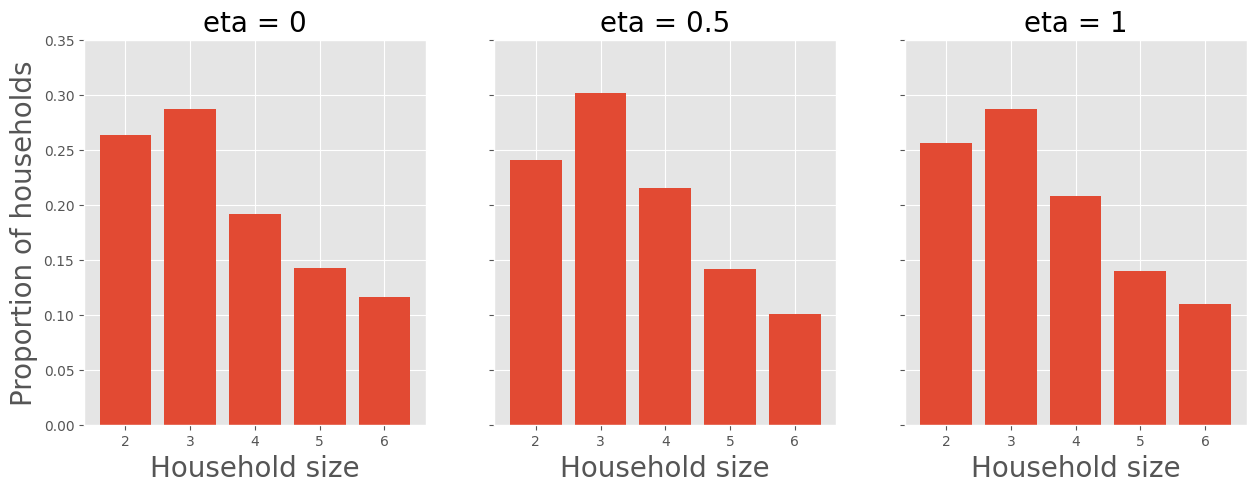

In [72]:
fig,axs = plt.subplots(1,3,figsize=(15,5),sharex = True,sharey = True)
axs[0].set_ylabel("Proportion of households",fontsize=20)
for i,eta in enumerate(eta_values):
    ax = axs[i]
    ax.set_title("eta = " + str(eta),fontsize=20)
    ax.bar(np.arange(2,m+2,1),np.mean(household_dist[eta],axis=0)/100)
    ax.set_xlabel("Household size",fontsize=20)

    ax.set_ylim(0,0.35)

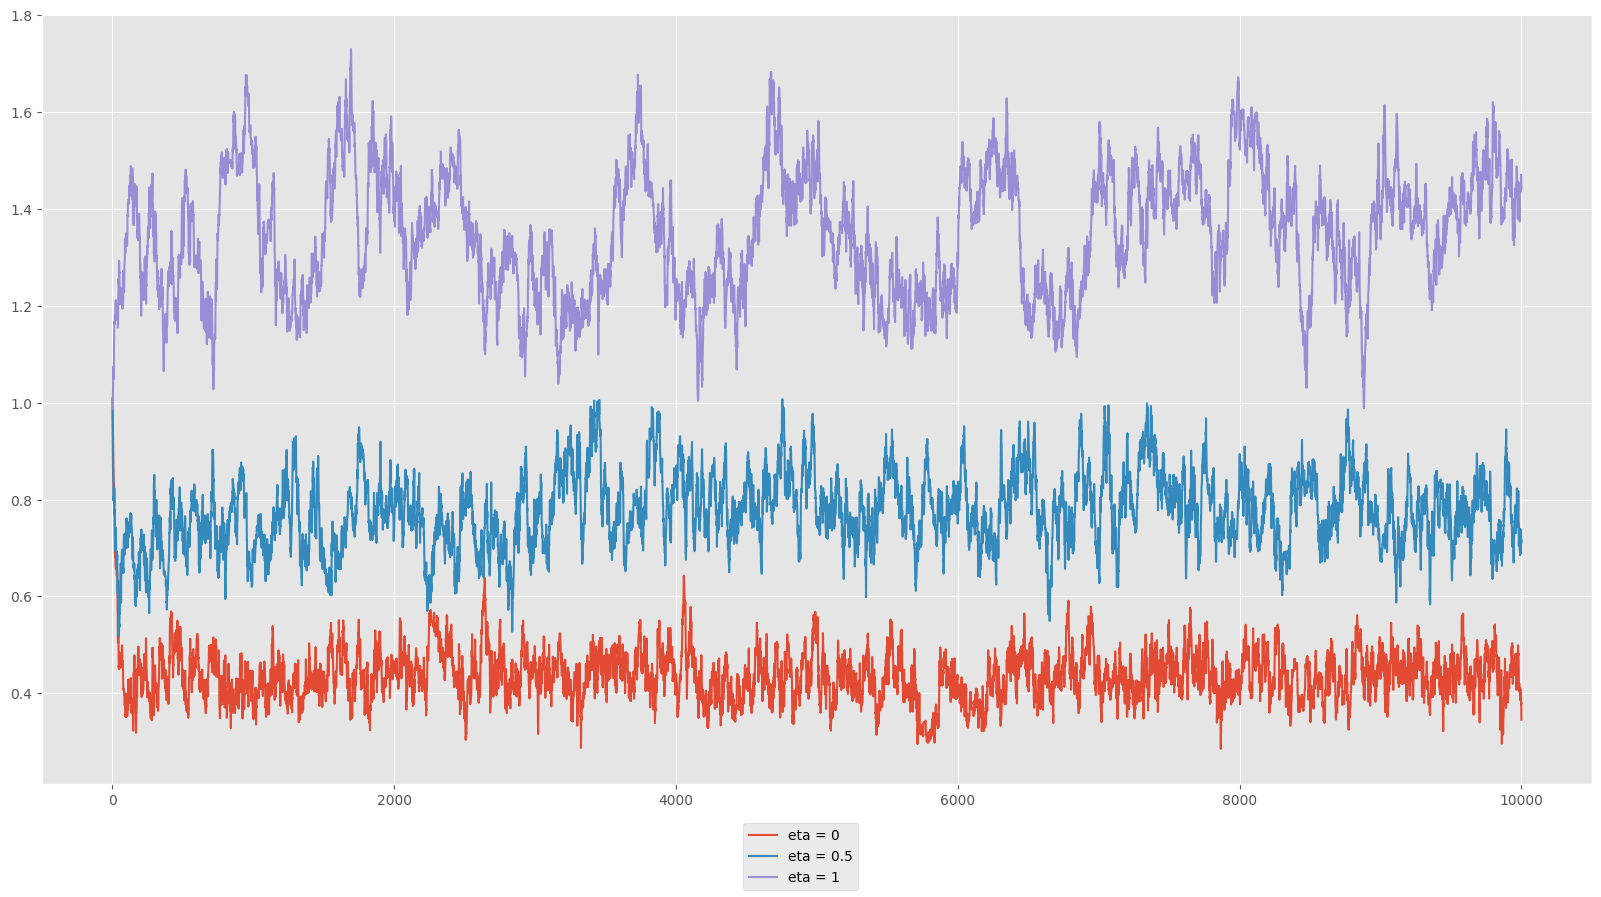

In [73]:
fig,ax =  plt.subplots(1,1,figsize = (20,10))

for eta in eta_values:
    plt.plot(results[eta][2],label = "eta = " + str(eta))
fig.legend(loc = "lower center")

# Test 6: How much does household size distribution matter

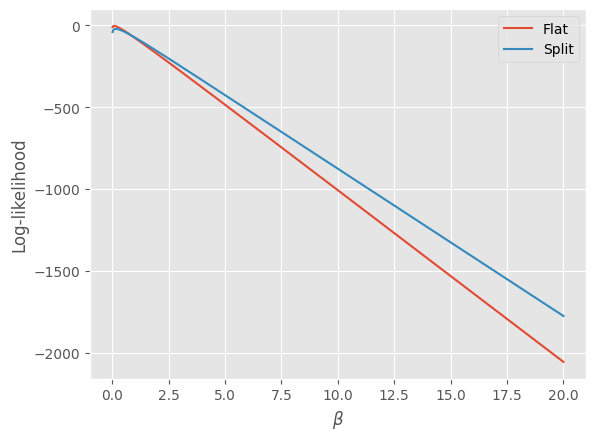

In [18]:
n= 400
y=10
N = 100
m=6

fp = FlatPartition(n,y,N,m)
sp = SplitPartition(n,y,N,m)

beta_values = np.linspace(0,20,1000)
ll_fp = np.zeros((len(beta_values)))
ll_sp = np.zeros((len(beta_values)))


for i,beta in enumerate(beta_values):
    final_size = FinalSizeDistributions(m,beta,eta=1)
    ll_fp[i] = PartitionLogLikelihood(fp,beta,m,final_size)
    ll_sp[i] = PartitionLogLikelihood(sp,beta,m,final_size)

plt.plot(beta_values,ll_fp,label = "Flat")
plt.plot(beta_values,ll_sp,label = "Split")
plt.xlabel(r"$\beta$")
plt.ylabel("Log-likelihood")
plt.legend()
    

# Fit to study data

## Allen et al
https://doi.org/10.1017/S0950268823000420

In [87]:
#Omicron data
n_o = 40123
N_o = 13680
y_o = 3812

In [88]:
if os.path.exists("testing_results/data_fits/allen_omicron_no_prior.pkl"):
    print("File found, loading results")
    with open("testing_results/data_fits/allen_omicron_no_prior.pkl","rb") as f:
        results_omicron_no_prior = load(f)

else:
    print("File not found, generating results")
    m=4
    C0 = FlatPartition(n_o,y_o,N_o,m)
    results_omicron_no_prior = RunPartitionsMCMC(C0,1,m,int(1e6),0.01,n_moves = 100,thin=10,verbose=True)
    with open("testing_results/data_fits/allen_omicron_no_prior.pkl","wb") as f:
        dump(results_omicron_no_prior,f)


if os.path.exists("testing_results/data_fits/allen_omicron_prior.pkl"):
    print("File found, loading results")
    with open("testing_results/data_fits/allen_omicron_prior.pkl","rb") as f:
        results_omicron_prior = load(f)

else:
    print("File not found, generating results")
    m=4
    C0 = FlatPartition(n_o,y_o,N_o,m)
    hh_dist_UK = [9698, 4526, 3961, 1249]  # 2023 UK household size distribution from size 2 to 6+
    hh_dist_UK = np.array(hh_dist_UK)*np.arange(2,6)
    hh_dist_UK = hh_dist_UK/sum(hh_dist_UK)
    results_omicron_prior = RunPartitionsMCMC(C0,1,m,int(1e6),0.01,n_moves = 100,thin=10,verbose=True,partition_prior =hh_dist_UK)
    with open("testing_results/data_fits/allen_omicron_prior.pkl","wb") as f:
        dump(results_omicron_prior,f)

File found, loading results
File found, loading results


In [89]:
C = np.array([4818,0,3373,0,0,3936,0,0,0,1551,0,0,0,0])

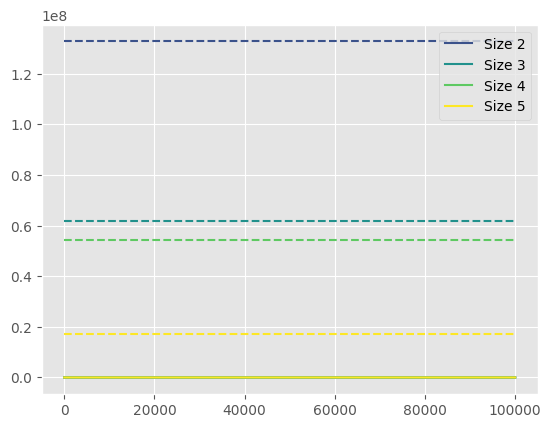

In [94]:
dot_for_contacts = np.concatenate([[i]*(i+1) for i in range(1,m+1)])
for i in range(1,m+1):
    color = plt.cm.viridis(i/m)
    plt.plot(np.where(dot_for_contacts == i,1,0).dot(results_omicron_prior[0].T),label = "Size " + str(i+1),color = color)
    plt.hlines(hh_dist_UK[i-1]*N_o,0,len(results_omicron_prior[0]),linestyles="--",color = color)
plt.legend()

## Jashaninejad et al.
10.34172/jrhs.2021.48

In [86]:
N = 323
n=989
y=314
m = 4

In [87]:

if os.path.exists("testing_results/data_fits/jashaninejad_no_prior.pkl"):
    print("File found, loading results")
    with open("testing_results/data_fits/jashaninejad_no_prior.pkl","rb") as f:
        results_no_prior = load(f)

else:
    print("File not found, generating results")
    C0 = np.array([12., 15., 23., 19., 14., 53., 24., 21., 12., 56., 25., 26., 19., 4.])
    beta0 = 0.8
    results_no_prior = RunPartitionsMCMC(C0,beta0,m,int(1e7),0.01,n_moves = 100,thin=10,verbose=True)
    with open("testing_results/data_fits/jashaninejad_no_prior.pkl","wb") as f:
        dump(results_no_prior,f)

File found, loading results


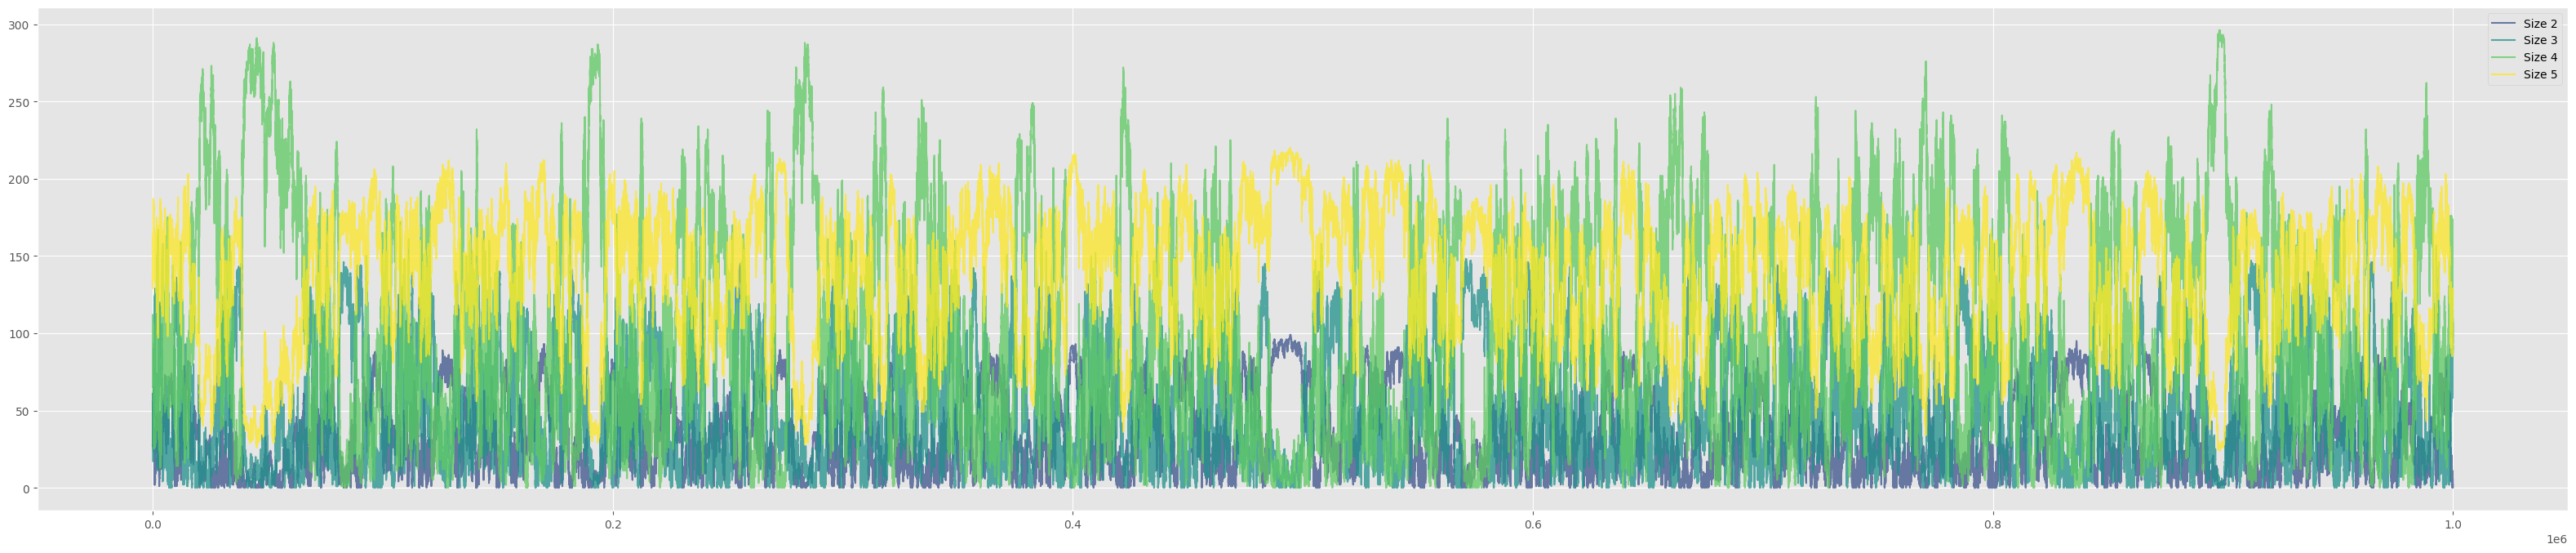

In [88]:
fig,ax = plt.subplots(figsize=(40,8))
dot_for_contacts = np.concatenate([[i]*(i+1) for i in range(1,m+1)])
for i in range(1,m+1):
    color = plt.cm.viridis(i/m)
    ax.plot(np.where(dot_for_contacts == i,1,0).dot(results_no_prior[0].T),label = "Size " + str(i+1),color = color,alpha= 0.75)
    #plt.hlines(hh_dist_UK[i-1]*N_o,0,len(results_no_prior[0]),linestyles="--",color = color)
ax.legend()


Text(0.5, 0, 'Iteration')

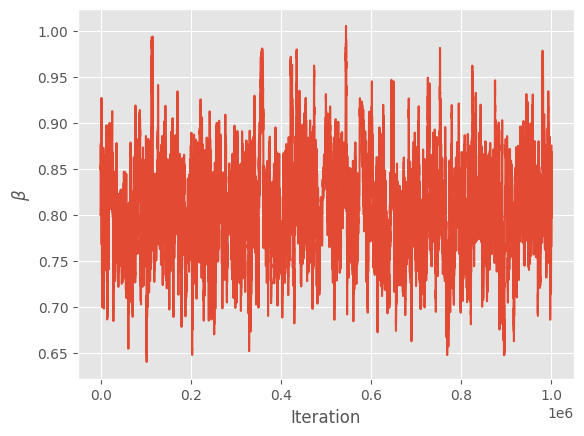

In [ ]:
plt.plot(results_no_prior[2])
plt.ylabel(r"$\beta$")
plt.xlabel("Iteration")

Text(0, 0.5, 'Density')

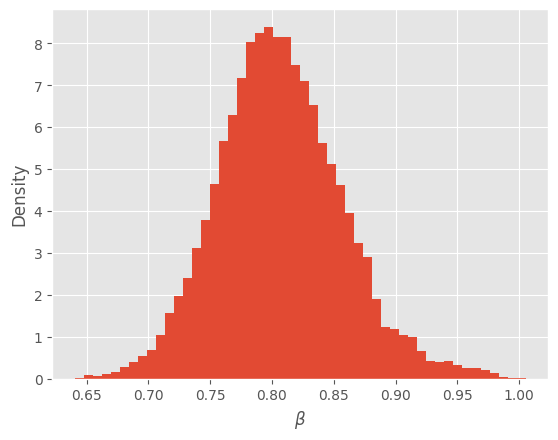

In [ ]:
plt.hist(results_no_prior[2],bins=50,density = True)
plt.xlabel(r"$\beta$")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

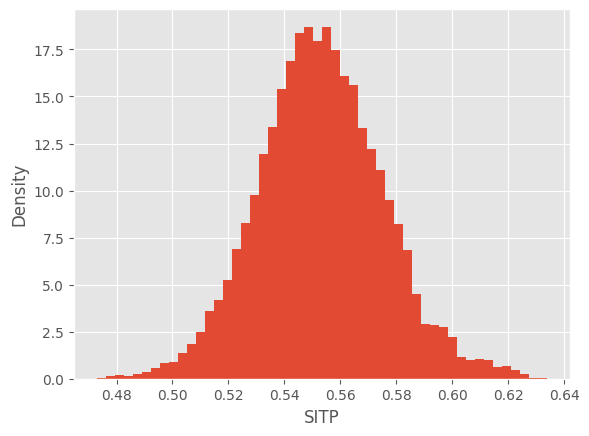

In [ ]:
plt.hist(1-np.exp(-results_no_prior[2]),bins=50,density = True)
plt.xlabel("SITP")
plt.ylabel("Density")

## Reukers et al
10.1093/cid/ciab237

In [89]:
n = 187
N = 55
y = 136-55
m=8
hh_size_dist_Reukers = np.array([ 0.,  9., 25., 15.,  4.,  1.,  0.,  1.])
hh_size_dist_Reukers = hh_size_dist_Reukers/sum(hh_size_dist_Reukers)


In [90]:
if os.path.exists("testing_results/data_fits/reukers_no_prior.pkl"):
    print("File found, loading results")
    with open("testing_results/data_fits/reukers_no_prior.pkl","rb") as f:
        results_no_prior = load(f)

else:
    print("File not found, generating results")
    C0 = FlatPartition(n,y,N,m)
    beta0 = 1
    results_no_prior = RunPartitionsMCMC(C0,beta0,m,int(1e7),0.01,n_moves = 100,thin=10,verbose=True)
    with open("testing_results/data_fits/reukers_no_prior.pkl","wb") as f:
        dump(results_no_prior,f)

File found, loading results


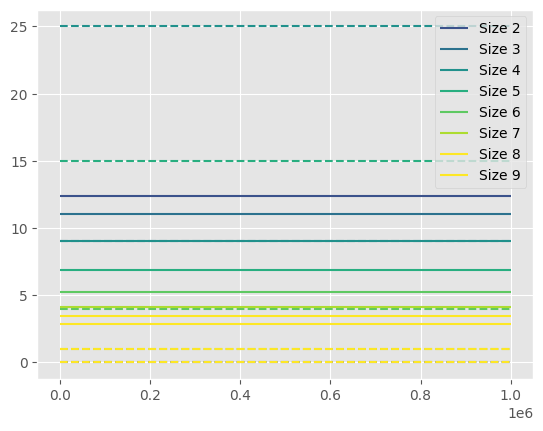

In [91]:
dot_for_contacts = np.concatenate([[i]*(i+1) for i in range(1,m+1)])
for i in range(2,m+2):
    color = plt.cm.viridis(i/m)
    plt.hlines(np.where(dot_for_contacts == i-1,1,0).dot(results_no_prior[0].T).mean(),0,len(results_no_prior[0]),label = "Size " + str(i),color = color)
    plt.hlines(hh_size_dist_Reukers[i-2]*N,0,len(results_no_prior[0]),linestyles="--",color = color) 
    plt.legend()

In [92]:
if os.path.exists("testing_results/data_fits/reukers_prior.pkl"):
    print("File found, loading results")
    with open("testing_results/data_fits/reukers_prior.pkl","rb") as f:
        results_prior = load(f)

else:
    print("File not found, generating results")
    C0 = FlatPartition(n,y,N,m)
    beta0 = 1
    results_prior = RunPartitionsMCMC(C0,beta0,m,int(1e7),0.01,n_moves = 100,thin=10,verbose=True,partition_prior=hh_size_dist_Reukers)
    with open("testing_results/data_fits/reukers_prior.pkl","wb") as f:
        dump(results_prior,f)

File found, loading results


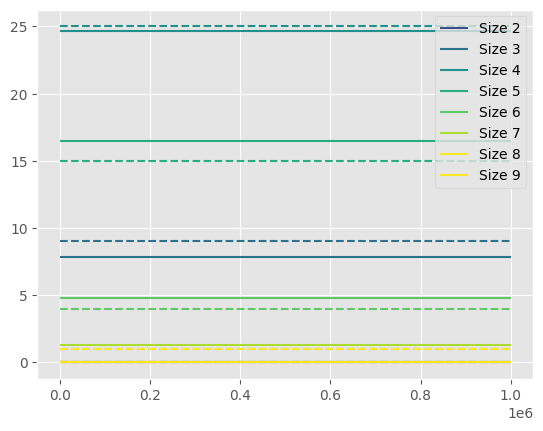

In [93]:
for i in range(2,m+2):
    color = plt.cm.viridis(i/m)
    plt.hlines(np.where(dot_for_contacts == i-1,1,0).dot(results_prior[0].T).mean(),0,len(results_prior[0]),label = "Size " + str(i),color = color)
    plt.hlines(hh_size_dist_Reukers[i-2]*N,0,len(results_prior[0]),linestyles="--",color = color) 
    plt.legend()

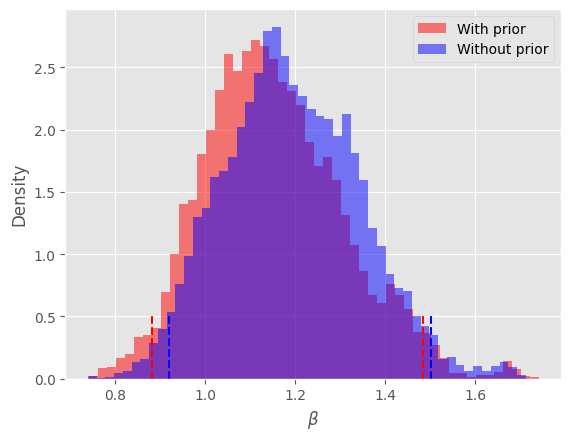

In [94]:
burn_in = len(results_prior[2])//5

plt.hist(results_prior[2][burn_in:],bins=50,density = True,label="With prior",alpha = 0.5,color="red")
plt.vlines(np.percentile(results_prior[2][burn_in:],[2.5,97.5]),0,0.5,linestyle="--",color = "red")
plt.hist(results_no_prior[2][burn_in:],bins=50,density = True,alpha = 0.5,label = "Without prior",color= "blue")
plt.vlines(np.percentile(results_no_prior[2][burn_in:],[2.5,97.5]),0,0.5,linestyle="--",color = "blue")
plt.xlabel(r"$\beta$")
plt.ylabel("Density")
plt.legend()

## Carazo  et al
10.1017/ice.2021.160

In [ ]:
n = 9096
N = 3823
y = 2718
hh_size_dist_Carazo = np.array([ 1335,809,984,442,156,97])
m = len(hh_size_dist_Carazo)
hh_size_dist_Carazo = hh_size_dist_Carazo/sum(hh_size_dist_Carazo)


In [101]:
if os.path.exists("testing_results/data_fits/Carazo_no_prior.pkl"):
    print("File found, loading results")
    with open("testing_results/data_fits/Carazo_no_prior.pkl","rb") as f:
        results_no_prior = load(f)

else:
    print("File not found, generating results")
    C0 = FlatPartition(n,y,N,m)
    beta0 = 1
    results_no_prior = RunPartitionsMCMC(C0,beta0,m,int(1e5),0.01,n_moves = 100,thin=10,verbose=True)
    with open("testing_results/data_fits/Carazo_no_prior.pkl","wb") as f:
        dump(results_no_prior,f)

File not found, generating results


Running MCMC: 100%|██████████| 100000/100000 [10:36<00:00, 157.01it/s]
